# Modelado 

In [97]:
import pandas as pd
import numpy as np 
import os

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn import metrics  

import statsmodels.api as sm

import warnings
warnings.filterwarnings('ignore') 

seed=27

In [98]:
def carga_info(data):
    drop_cols = [
        'Municipio', 
        'Departamento', 
        'EVI_Min_Date', 
        'EVI_Max_Date', 
        'NDVI_Min_Date', 
        'NDVI_Max_Date', 
        'NDVI_Max_Count', 
        #'Latitude', 
        #'Longitude', 
        'Producto', 
        'Área Cosechada', 
        'Área Sembrada', 
        'Ciclo',
        'Producción'
        ]
    
    #Creación de nuevas variables necesarias
    data['Mpio'] = data['Municipio'].str.strip()+'_'+data['Departamento'].str.strip()
    data['Flag_covid'] = np.where(data['Year']==2020, 1, 0)
    data.rename(columns={'EVI_Max_Count':'Resolucion'}, inplace=True)
    #Eliminación de columnas innecesarias
    data.drop(columns=drop_cols, inplace=True)
    #Eliminación de nuelos -- esto puede cambiar si decidimos hacer imputacion
    data.dropna(inplace=True)
    #Ordenamiento
    data = data[[
        'Year', 'Mpio', 
        't2m_mean', 'd2m_mean', 'tp_mean', 'ssrd_mean', 'e_mean', 'stl1_mean', 
        't2m_std', 'd2m_std', 'tp_std', 'ssrd_std', 'e_std', 'stl1_std', 
        'Resolucion',
       'EVI_Min_Minimum', 'EVI_Max_Maximum', 'EVI_Avg_StdDev', 'EVI_Avg_Mean_deviation', 'EVI_Avg_StdDev_deviation',
       'EVI_Median_Median', 'EVI_Avg_Mean', 'NDVI_Min_Minimum', 'NDVI_Avg_Mean_deviation', 'NDVI_Avg_StdDev_deviation',
       'NDVI_Max_Maximum', 'NDVI_Avg_StdDev', 'NDVI_Median_Median',
       'NDVI_Avg_Mean', 'Flag_covid', 'Rendimiento']]
    
    print(f'Data cargada para {data}')
    data.info()
    return data

def univariate_ols_analysis(df, target='Rendimiento', test_size=0.2, random_state=42, verbose=True):
    
    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        df.drop(columns=[target]),
        df[target],
        test_size=test_size,
        random_state=random_state
    )
    
    predictors = X_train.columns
    results = []
    
    for pred in predictors:
        
        X = X_train[[pred]].copy()
        
        # Convertir categóricas a dummies
        if X.dtypes[0] == 'object':
            X = pd.get_dummies(X, drop_first=True)
        
            # Agregar intercepto
        X = sm.add_constant(X)
        
        # Fit modelo
        mod = sm.OLS(y_train, X)
        res = mod.fit()
        
        if verbose:
            print(f"\nResultados para predictor: {pred}")
            print(res.summary())
        
        # Extraer coeficiente y p-value (puede haber varias columnas si hubo dummies)
        for var in X.columns:
            if var != 'const':
                results.append({
                    'predictor': pred,
                    'variable_model': var,
                    'R2': res.rsquared,
                    'F_stat': res.fvalue,
                    'coef': res.params[var],
                    'p_value': res.pvalues[var],
                })
    
    df_results = pd.DataFrame(results)
    df_results.sort_values(by='R2', ascending=False, inplace=True)
    df_results.reset_index(drop=True, inplace=True)
    
    return df_results

def univariate_ols_analysis(df, target='Rendimiento', test_size=0.2, random_state=42, verbose=True):
    
    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        df.drop(columns=[target]),
        df[target],
        test_size=test_size,
        random_state=random_state
    )
    
    results = []
    
    for pred in X_train.columns:
        
        X = X_train[[pred]].copy()
        
        # Convertir categóricas a dummies SI es necesario
        if X.dtypes.iloc[0] == 'object' or str(X.dtypes.iloc[0]).startswith('category'):
            X = pd.get_dummies(X, drop_first=True)
        
        # 🔑 FORZAR a numérico (CLAVE para evitar tu error)
        X = X.apply(pd.to_numeric, errors='coerce')
        y = pd.to_numeric(y_train, errors='coerce')
        
        # Eliminar NaNs generados
        data = pd.concat([X, y], axis=1).dropna()
        X_clean = data.drop(columns=[target])
        y_clean = data[target]
        
        # Agregar constante
        X_clean = sm.add_constant(X_clean)
        
        # Fit
        try:
            mod = sm.OLS(y_clean, X_clean)
            res = mod.fit()
        except Exception as e:
            print(f"Error con predictor {pred}: {e}")
            continue
        
        if verbose:
            print(f"\nResultados para predictor: {pred}")
            print(res.summary())
        
        # Extraer resultados
        for var in X_clean.columns:
            if var != 'const':
                results.append({
                    'predictor': pred,
                    'variable_model': var,
                    'R2': res.rsquared,
                    'F_stat': res.fvalue,
                    'coef': res.params[var],
                    'p_value': res.pvalues[var],
                })
    
    df_results = pd.DataFrame(results)
    df_results.sort_values(by='R2', ascending=False, inplace=True)
    df_results.reset_index(drop=True, inplace=True)
    
    return df_results

def plot_corr_with_target(df, target='Rendimiento', drop_cols=None, plot=True):
    
    # Copia del df
    data = df.copy()
    
    # Eliminar columnas si se especifica
    if drop_cols:
        data = data.drop(columns=drop_cols)
    
    # Mantener solo numéricas (evita errores)
    data = data.select_dtypes(include='number')
    
    # Correlación
    corr_df = data.corr()
    
    # Plot
    if plot:
        plt.figure(figsize=(16,9))
        sns.heatmap(
            corr_df,
            cmap='coolwarm',
            center=0,
            annot=True,
            fmt=".2f",
            linewidths=0.2
        )
        plt.title("Correlation Matrix")
        plt.show()
    
    # Ranking respecto al target
    corr_target = corr_df[target].sort_values(ascending=False)
    
    return corr_df, corr_target

def random_forest_feature_importance(
    df,
    target='Rendimiento',
    drop_cols=None,
    test_size=0.2,
    random_state=42,
    n_estimators=100
):
    
    # Copia del dataframe
    data = df.copy()
    
    # Eliminar columnas si aplica
    if drop_cols:
        data = data.drop(columns=drop_cols)
    
    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        data.drop(columns=[target]),
        data[target],
        test_size=test_size,
        random_state=random_state
    )
    
    # Modelo
    RF = RandomForestRegressor(
        random_state=random_state,
        n_estimators=n_estimators
    )
    
    RF.fit(X_train, y_train)
    
    # Feature importance
    feat_imp_df = pd.DataFrame({
        'feature': RF.feature_names_in_,
        'importance': RF.feature_importances_
    })
    
    feat_imp_df = feat_imp_df.sort_values(by='importance', ascending=False).reset_index(drop=True)
    
    return feat_imp_df, RF

def model_evaluation(df, target, feats, model, run_name):
    X_total = df[feats]
    X_total_dummies = pd.get_dummies(X_total, drop_first=True)
    year_mpio = df[['Year', 'Mpio']+[target]]

    #Registros fuera del tiempo (OOT)
    df_oot = df[df['Year'].isin([2024])]
    df_oot = df_oot[[target]+feats]
    df_oot_dummies = pd.get_dummies(df_oot, drop_first=True)
    X_oot = df_oot_dummies.drop(columns=[target])
    X_oot = X_oot.reindex(columns=X_oot.columns, fill_value=0)
    y_oot = df_oot_dummies[[target]]

    #Registros en el tiempo (IT)
    df_it = df[~df['Year'].isin([2024])]
    df_it = df_it[[target]+feats]
    df_it_dummies = pd.get_dummies(df_it, drop_first=True)

    X = df_it_dummies.drop(columns=[target])
    Y= df_it_dummies[[target]]

    X_train, X_test, y_train, y_test = train_test_split(X, Y , test_size=0.25, random_state=seed)

    #Entrenamiento del modelo
    model.fit(X_train,y_train)

    #Predicciones de prueba
    y_pred_it_train = model.predict(X_train)
    y_pred_it_test = model.predict(X_test)
    y_pred_oot = model.predict(X_oot)
    
    #Predicciones totales
    X_total_dummies['Rendimiento_Predicho'] = model.predict(X_total_dummies)
    total_pred = pd.concat([year_mpio, X_total_dummies], axis=1)

    #Evaluación del modelo
    mse_it_train = metrics.mean_squared_error(y_train.values.ravel(), y_pred_it_train)
    mse_it_test = metrics.mean_squared_error(y_test.values.ravel(), y_pred_it_test)
    mse_oot = metrics.mean_squared_error(y_oot.values.ravel(), y_pred_oot)

    rmse_it_train = np.sqrt(mse_it_train)
    rmse_it_test = np.sqrt(mse_it_test)
    rmse_oot = np.sqrt(mse_oot)

    df_results = pd.DataFrame({
        'run_name' : [run_name],
        'MSE_IT_Train': [mse_it_train],
        'MSE_IT_Test': [mse_it_test],
        'MSE_OOT': [mse_oot],
        'RMSE_IT_Train': [rmse_it_train],
        'RMSE_IT_Test': [rmse_it_test],
        'RMSE_OOT': [rmse_oot]
    })

    return df_results, model, total_pred

In [99]:
#Selección de variables
feats_select_regresion=[
 'EVI_Avg_Mean_deviation',
 'ssrd_mean',
 'EVI_Median_Median',
 'ssrd_std',
 'd2m_std',
 'EVI_Avg_Mean',
 'NDVI_Max_Maximum',
 'EVI_Max_Maximum',
 'e_std',
 'Flag_covid'
 ]

feats_select_imp = [
 'EVI_Avg_Mean_deviation',
 'ssrd_mean',
 'ssrd_std',
 'EVI_Median_Median',
 'd2m_std',
 'e_std',
 'NDVI_Avg_Mean_deviation',
 'stl1_std',
 'tp_std',
 'NDVI_Max_Maximum',
 'tp_mean',
 'Flag_covid']

feats_select_total = [
 'EVI_Avg_Mean_deviation',
 'ssrd_mean',
 'ssrd_std',
 'EVI_Median_Median',
 'd2m_std',
 'e_std',
 'NDVI_Avg_Mean_deviation',
 'stl1_std',
 'tp_std',
 'NDVI_Max_Maximum',
 'tp_mean',
 'EVI_Max_Maximum',
 'Flag_covid',
 'Mpio']

In [100]:
df_ago_nov = pd.read_excel("../Data anual/data_anual_ago_nov.xlsx")
df_sep_dec = pd.read_excel("../Data anual/data_anual_sep_dec.xlsx")
df_total = pd.read_excel("../Data anual/data_anual_total.xlsx")

df_ago_nov = carga_info(df_ago_nov)
df_sep_dec = carga_info(df_sep_dec)
df_total = carga_info(df_total)

data_bases = {
    'Agosto Noviembre': df_ago_nov,
    'Septiembre Diciembre': df_sep_dec,
    'Total anual': df_total
}
modelos = [LinearRegression(), RandomForestRegressor(random_state=seed), HistGradientBoostingRegressor(random_state=seed)]

Data cargada para      Year                         Mpio  t2m_mean  d2m_mean   tp_mean  \
0    2007             MONIQUIRA_BOYACA   14.8025   11.7700  0.007746   
1    2008             MONIQUIRA_BOYACA   14.8300   11.9650  0.007302   
2    2009             MONIQUIRA_BOYACA   15.7175   11.6800  0.005707   
3    2010             MONIQUIRA_BOYACA   15.0000   12.2750  0.008864   
4    2011             MONIQUIRA_BOYACA   15.0975   11.8325  0.007635   
..    ...                          ...       ...       ...       ...   
427  2020  VALLE DE SAN JOSE_SANTANDER   18.2800   15.5525  0.015731   
428  2021  VALLE DE SAN JOSE_SANTANDER   18.3925   15.3675  0.013376   
429  2022  VALLE DE SAN JOSE_SANTANDER   18.0450   15.2600  0.013582   
430  2023  VALLE DE SAN JOSE_SANTANDER   19.1375   16.0350  0.012559   
431  2024  VALLE DE SAN JOSE_SANTANDER   18.9775   15.9050  0.014026   

      ssrd_mean    e_mean  stl1_mean   t2m_std   d2m_std  ...  EVI_Avg_Mean  \
0    17856799.0 -0.003116    14.9900  

## Comparacion de modelos base

In [101]:
modelos_fitted = {}
backtest_results = {}
df_Resultados_Agregados = pd.DataFrame()

for data_base in list(data_bases.keys()):
    for model in modelos:
        run_name = f"{data_base}_{model.__class__.__name__}"
        print(f"Ejecutando: {run_name}")
        df_results, fitted_model, total_pred = model_evaluation(
            df=data_bases[data_base],
            target='Rendimiento',
            feats=feats_select_total,
            model=model,
            run_name=run_name
        )
        df_Resultados_Agregados = pd.concat([df_Resultados_Agregados, df_results], axis=0)
        modelos_fitted[run_name] = fitted_model
        backtest_results[run_name] = total_pred

df_Resultados_Agregados.sort_values(by='MSE_OOT', inplace=True, ascending=True)

Ejecutando: Agosto Noviembre_LinearRegression
Ejecutando: Agosto Noviembre_RandomForestRegressor
Ejecutando: Agosto Noviembre_HistGradientBoostingRegressor
Ejecutando: Septiembre Diciembre_LinearRegression
Ejecutando: Septiembre Diciembre_RandomForestRegressor
Ejecutando: Septiembre Diciembre_HistGradientBoostingRegressor
Ejecutando: Total anual_LinearRegression
Ejecutando: Total anual_RandomForestRegressor
Ejecutando: Total anual_HistGradientBoostingRegressor


In [102]:
df_Resultados_Agregados

,run_name,MSE_IT_Train,MSE_IT_Test,MSE_OOT,RMSE_IT_Train,RMSE_IT_Test,RMSE_OOT
0,Total anual_RandomForestRegressor,0.007133,0.075434,0.070818,0.084459,0.274653,0.266117
0,Total anual_LinearRegression,0.048069,0.071978,0.071061,0.219245,0.268287,0.266573
0,Total anual_HistGradientBoostingRegressor,0.005314,0.079871,0.085499,0.072897,0.282614,0.292401
0,Septiembre Diciembre_LinearRegression,0.048617,0.068260,0.100231,0.220493,0.261267,0.316593
0,Septiembre Diciembre_RandomForestRegressor,0.008456,0.067415,0.101046,0.091957,0.259645,0.317878
0,Agosto Noviembre_RandomForestRegressor,0.009128,0.069603,0.112352,0.095543,0.263824,0.335190
0,Septiembre Diciembre_HistGradientBoostingRegre...,0.006346,0.075625,0.129000,0.079660,0.275001,0.359165
0,Agosto Noviembre_HistGradientBoostingRegressor,0.006475,0.071734,0.157357,0.080470,0.267832,0.396682
0,Agosto Noviembre_LinearRegression,0.049035,0.068829,0.197634,0.221438,0.262353,0.444560


## Resultados del score total

In [103]:
def plot_actual_vs_predicted(selected_run):
    for Mpio in list(backtest_results[selected_run]['Mpio'].unique()):
        print(f'Processing {Mpio}')
        df_plot = backtest_results[selected_run].copy()
        df_plot = df_plot[df_plot['Mpio']==Mpio]
        # robustly detect column names
        real_col = 'Rendimiento' if 'Rendimiento' in df_plot.columns else ('Rendimiento_Real' if 'Rendimiento_Real' in df_plot.columns else None)
        pred_col = 'Rendimiento_Predicho' if 'Rendimiento_Predicho' in df_plot.columns else ('Rendimiento_Predicted' if 'Rendimiento_Predicted' in df_plot.columns else None)

        if real_col is None or pred_col is None:
            print('Available columns in selected run:', df_plot.columns.tolist())
            raise ValueError('Expected columns not found: need actual (`Rendimiento` or `Rendimiento_Real`) and predicted (`Rendimiento_Predicho`).')

        # ensure numeric Year
        df_plot['Year'] = pd.to_numeric(df_plot['Year'], errors='coerce')
        grouped = df_plot.groupby('Year')[[real_col, pred_col]].mean().reset_index().sort_values('Year')
        grouped['diff'] = grouped[pred_col] - grouped[real_col]

        plt.figure(figsize=(10,5))
        sns.lineplot(data=grouped, x='Year', y=real_col, marker='o', label='Rendimiento')
        sns.lineplot(data=grouped, x='Year', y=pred_col, marker='o', label='Rendimiento_Predicho')
        plt.title(f'{Mpio}: Actual vs Predicted by Year — {selected_run}')
        plt.xlabel('Year')
        plt.ylabel('Rendimiento')
        plt.grid(axis='y', linestyle='--', alpha=0.4)
        plt.legend()
        plt.show()

        plt.figure(figsize=(10,4))
        sns.barplot(data=grouped, x='Year', y='diff', palette='vlag')
        plt.axhline(0, color='k', linewidth=0.8)
        plt.title(f'{Mpio}: Prediction minus Actual (by Year) — {selected_run}')
        plt.xlabel('Year')
        plt.ylabel('Predicted - Actual')
        plt.show()

        print("\n")
        # show table
        display(grouped)

### Total de informacion anual + Random Forest

Text(0, 0.5, 'Rendimiento Predicho')

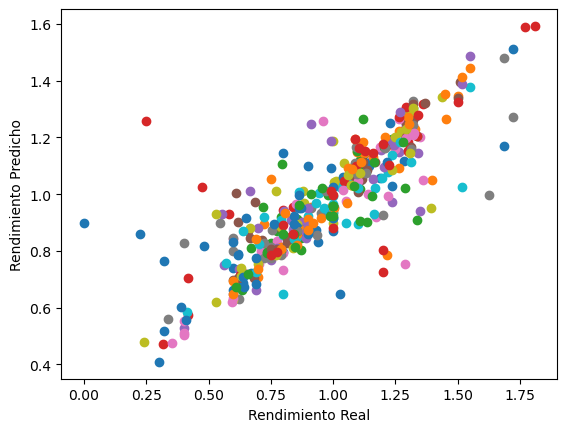

In [104]:
df_plot = backtest_results['Total anual_RandomForestRegressor'].copy()
df_plot.groupby('Mpio').apply(lambda x: plt.scatter(x['Rendimiento'], x['Rendimiento_Predicho'], label=x.name))
plt.xlabel('Rendimiento Real')
plt.ylabel('Rendimiento Predicho')

In [105]:
df_plot = backtest_results['Total anual_RandomForestRegressor'].copy()
df_plot['Error'] = df_plot['Rendimiento'] - df_plot['Rendimiento_Predicho']
df_plot['Abs_Error'] = df_plot['Error'].abs()
pred_error_mpio = df_plot.groupby('Mpio').mean()[['Error', 'Abs_Error', 'Rendimiento', 'Rendimiento_Predicho']]
pred_error_mpio.sort_values(by='Abs_Error', ascending=True, inplace=True)
pred_error_mpio

,Error,Abs_Error,Rendimiento,Rendimiento_Predicho
Mpio,,,,
SUAITA_SANTANDER,-0.007642,0.057565,0.981958,0.989600
PALMAS DEL SOCORRO_SANTANDER,-0.000128,0.059312,1.026859,1.026987
PINCHOTE_SANTANDER,-0.013394,0.064072,0.960383,0.973777
OCAMONTE_SANTANDER,0.039219,0.064612,1.096438,1.057219
CHARALA_SANTANDER,0.009037,0.074367,1.015501,1.006464
GUADALUPE_SANTANDER,0.016001,0.077905,0.975065,0.959064
EL SOCORRO_SANTANDER,0.002564,0.079635,1.003430,1.000866
PARAMO_SANTANDER,0.012700,0.080319,1.033686,1.020986
OIBA_SANTANDER,-0.038635,0.081126,0.959842,0.998477


Processing MONIQUIRA_BOYACA


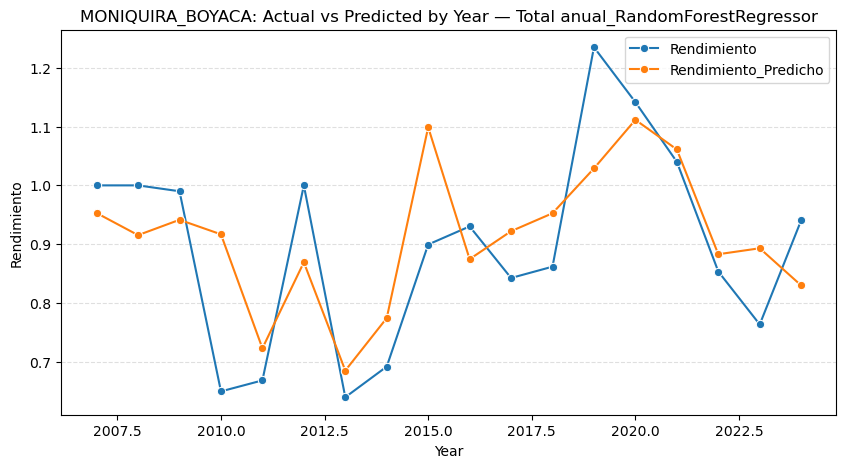

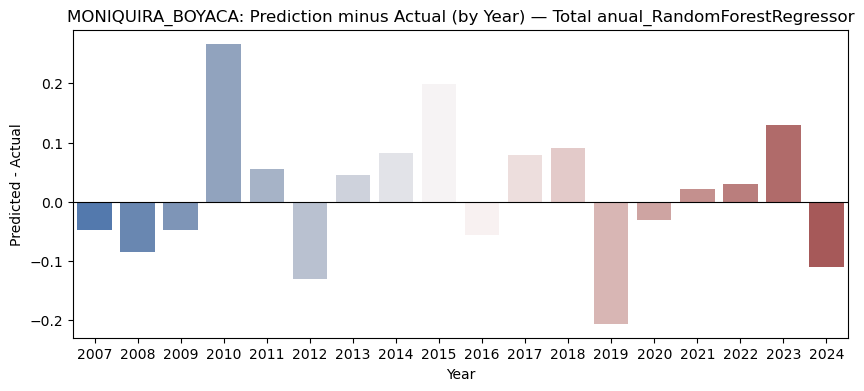

,Year,Rendimiento,Rendimiento_Predicho,diff
0,2007,1.000000,0.952972,-0.047028
1,2008,1.000000,0.915450,-0.084550
2,2009,0.990000,0.941505,-0.048495
3,2010,0.650000,0.916845,0.266845
4,2011,0.668693,0.723220,0.054527
5,2012,1.000000,0.869344,-0.130656
6,2013,0.640093,0.685365,0.045272
7,2014,0.692126,0.774577,0.082451
8,2015,0.899531,1.098802,0.199270
9,2016,0.930295,0.874683,-0.055612


Processing SAN JOSE DE PARE_BOYACA


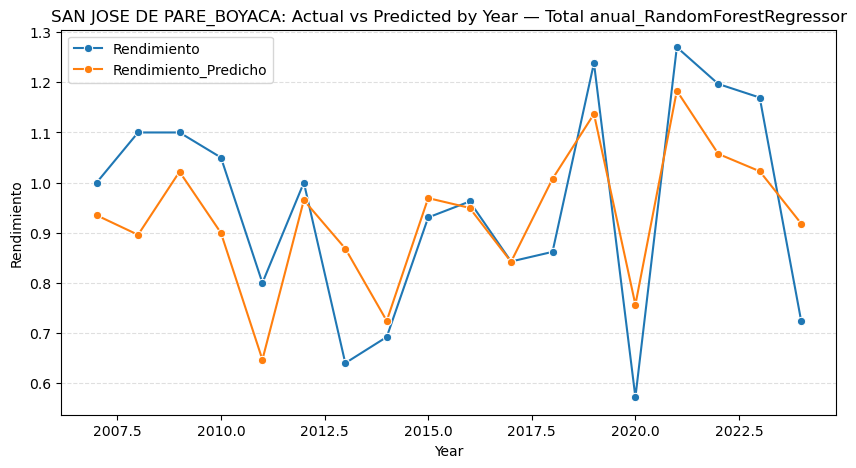

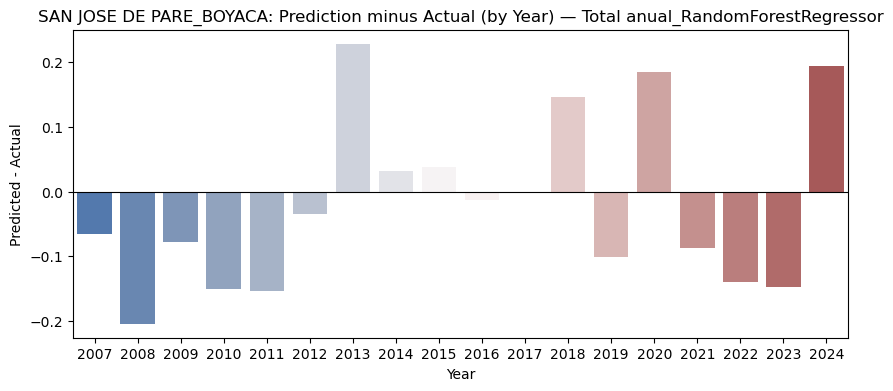

,Year,Rendimiento,Rendimiento_Predicho,diff
0,2007,1.000000,0.934889,-0.065111
1,2008,1.100000,0.895862,-0.204138
2,2009,1.100000,1.021766,-0.078234
3,2010,1.050000,0.899640,-0.150360
4,2011,0.800000,0.646916,-0.153084
5,2012,1.000000,0.964965,-0.035035
6,2013,0.640093,0.868488,0.228396
7,2014,0.692126,0.724327,0.032201
8,2015,0.930519,0.969108,0.038589
9,2016,0.962342,0.949613,-0.012729


Processing SANTANA_BOYACA


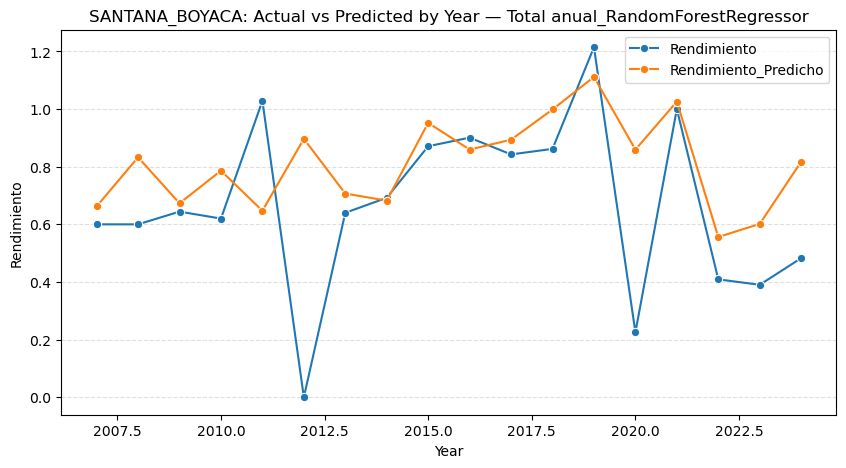

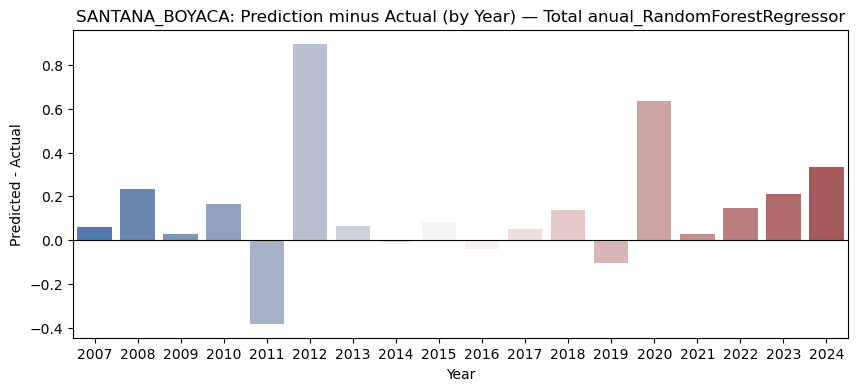

,Year,Rendimiento,Rendimiento_Predicho,diff
0,2007,0.600000,0.662259,0.062259
1,2008,0.600000,0.832785,0.232785
2,2009,0.644185,0.673050,0.028865
3,2010,0.620000,0.786188,0.166188
4,2011,1.028571,0.647143,-0.381429
5,2012,0.000000,0.896767,0.896767
6,2013,0.640092,0.706742,0.066650
7,2014,0.692127,0.682361,-0.009766
8,2015,0.871101,0.952219,0.081117
9,2016,0.900895,0.859500,-0.041394


Processing TOGUI_BOYACA


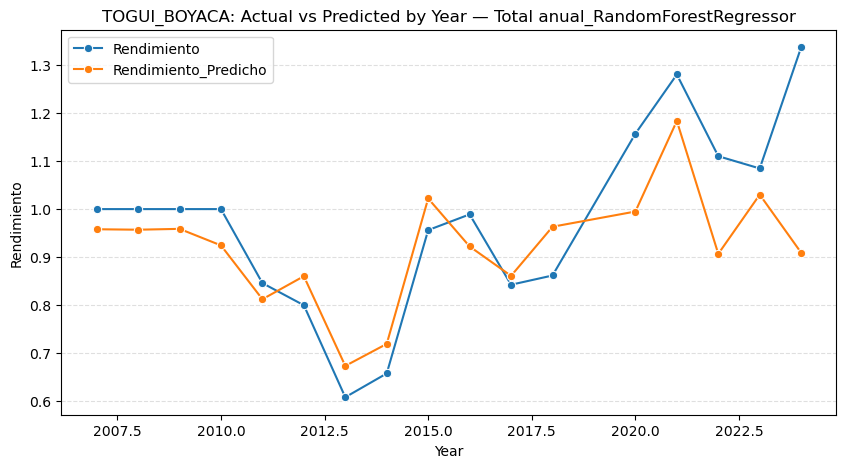

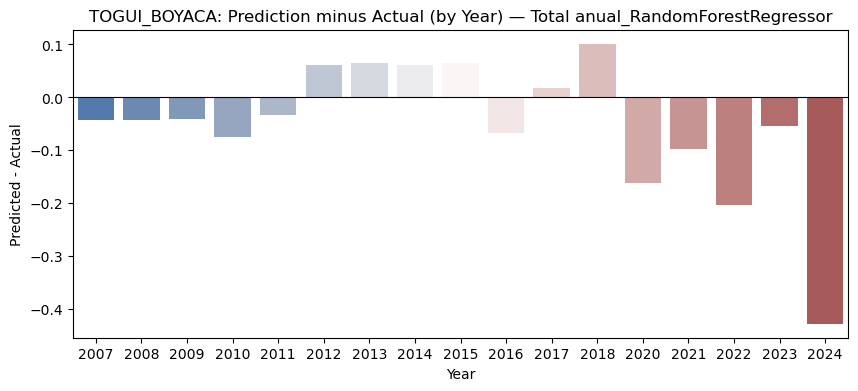

,Year,Rendimiento,Rendimiento_Predicho,diff
0,2007,1.000000,0.958076,-0.041924
1,2008,1.000000,0.957121,-0.042879
2,2009,1.000000,0.958900,-0.041100
3,2010,1.000000,0.924511,-0.075489
4,2011,0.846037,0.812521,-0.033516
5,2012,0.800000,0.860388,0.060388
6,2013,0.608660,0.673805,0.065145
7,2014,0.658138,0.719599,0.061461
8,2015,0.956296,1.022063,0.065767
9,2016,0.989003,0.922276,-0.066728


Processing AGUADA_SANTANDER


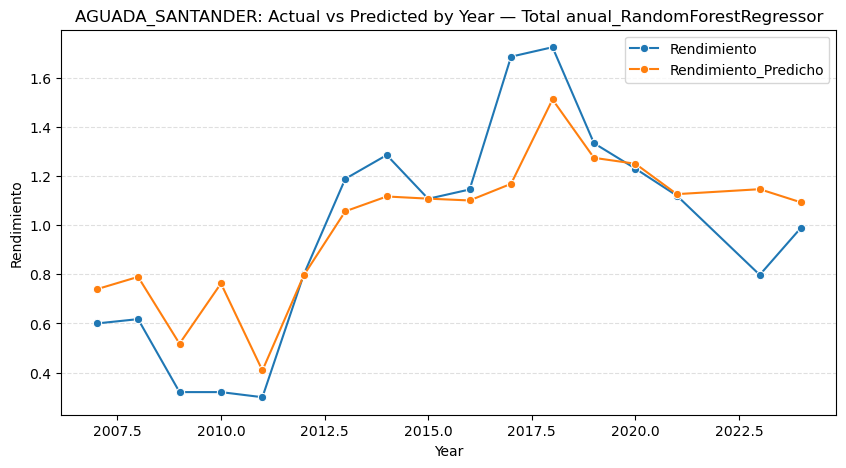

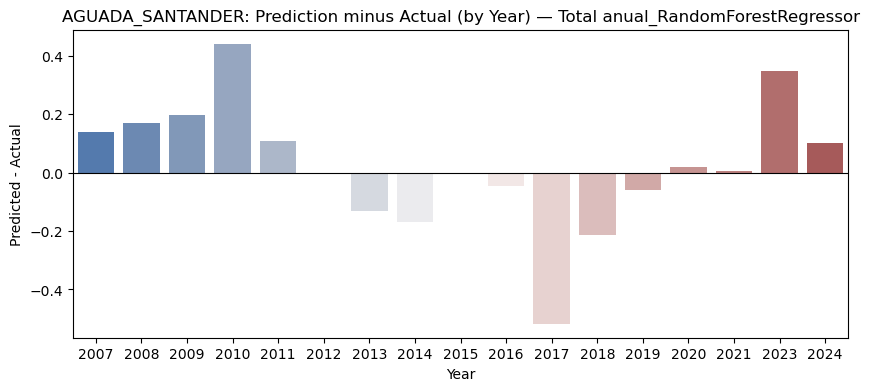

,Year,Rendimiento,Rendimiento_Predicho,diff
0,2007,0.600000,0.739151,0.139151
1,2008,0.617647,0.789583,0.171936
2,2009,0.320836,0.517793,0.196957
3,2010,0.320836,0.762769,0.441933
4,2011,0.300000,0.408759,0.108759
5,2012,0.800000,0.796252,-0.003748
6,2013,1.188496,1.056330,-0.132166
7,2014,1.285110,1.116597,-0.168513
8,2015,1.107177,1.107761,0.000584
9,2016,1.145044,1.100416,-0.044628


Processing BARBOSA_SANTANDER


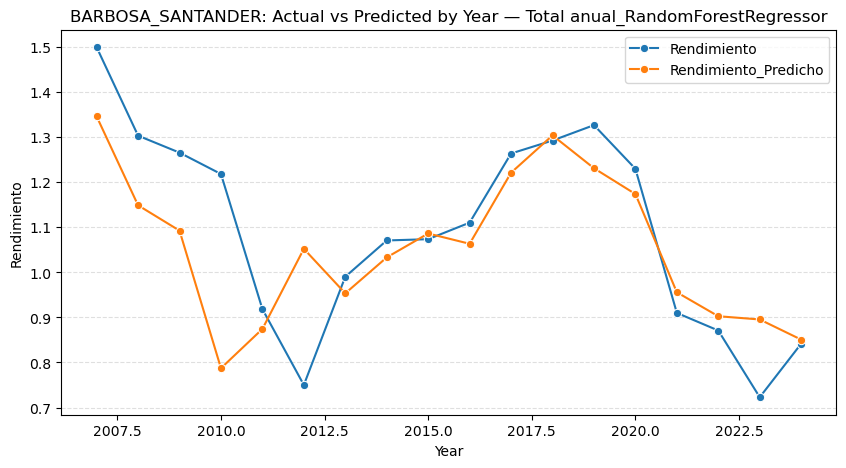

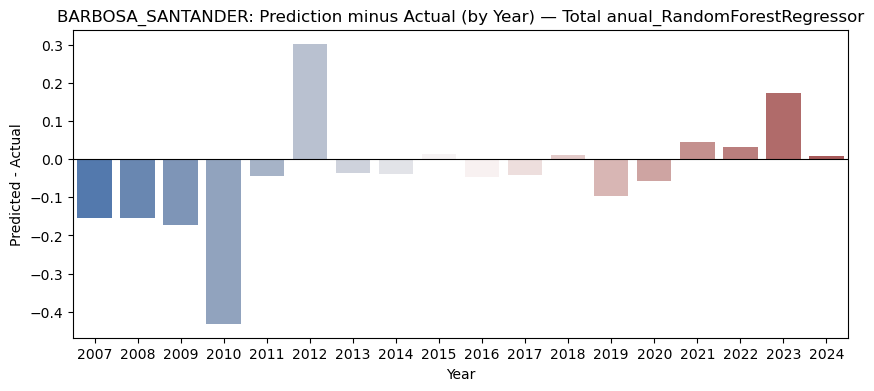

,Year,Rendimiento,Rendimiento_Predicho,diff
0,2007,1.500000,1.346380,-0.153620
1,2008,1.303614,1.148961,-0.154654
2,2009,1.265922,1.092737,-0.173186
3,2010,1.218450,0.787226,-0.431224
4,2011,0.918451,0.874431,-0.044020
5,2012,0.750000,1.052377,0.302377
6,2013,0.990413,0.953524,-0.036889
7,2014,1.070925,1.033273,-0.037652
8,2015,1.073733,1.086370,0.012637
9,2016,1.110455,1.063541,-0.046914


Processing CHARALA_SANTANDER


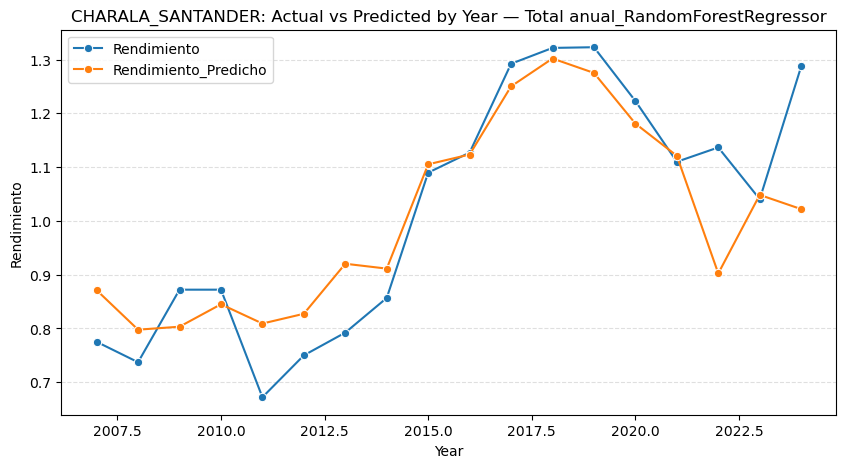

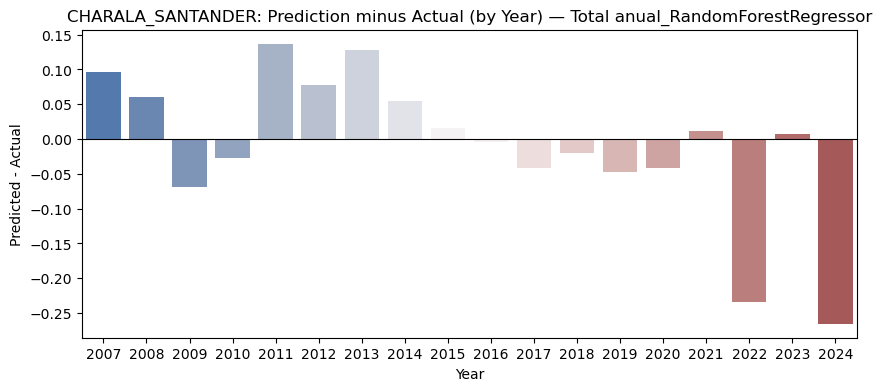

,Year,Rendimiento,Rendimiento_Predicho,diff
0,2007,0.775172,0.871178,0.096006
1,2008,0.737206,0.797741,0.060535
2,2009,0.872147,0.803270,-0.068877
3,2010,0.872146,0.845018,-0.027128
4,2011,0.672147,0.809160,0.137013
5,2012,0.750000,0.827315,0.077315
6,2013,0.792330,0.920357,0.128027
7,2014,0.856739,0.911307,0.054568
8,2015,1.089778,1.105244,0.015467
9,2016,1.127056,1.123480,-0.003576


Processing CHIPATA_SANTANDER


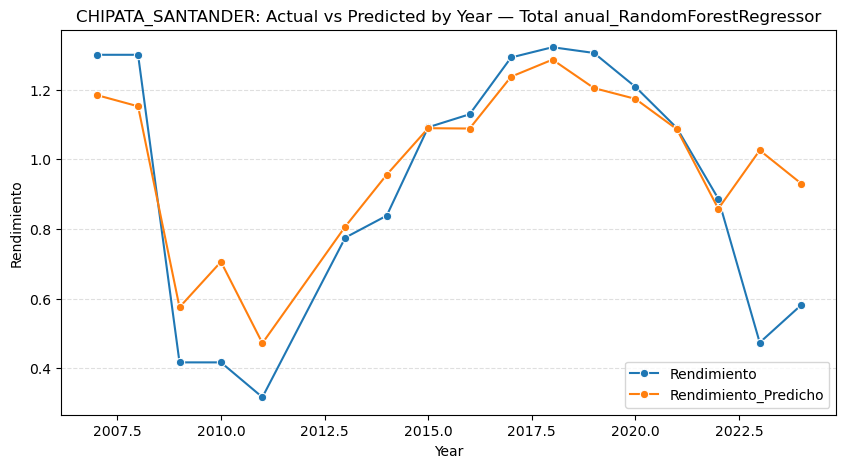

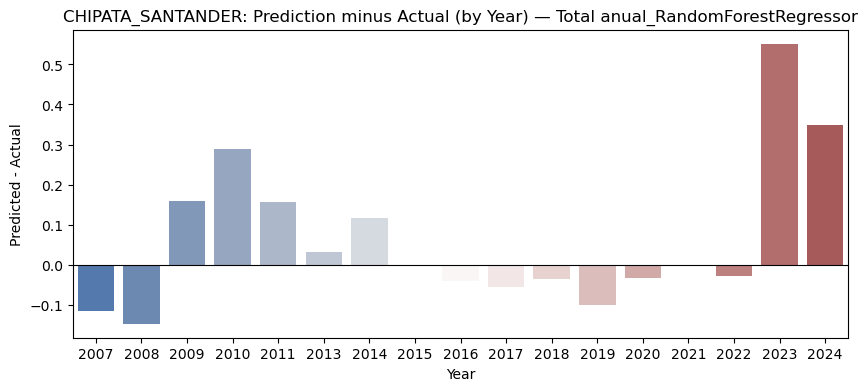

,Year,Rendimiento,Rendimiento_Predicho,diff
0,2007,1.300000,1.184494,-0.115506
1,2008,1.300000,1.152127,-0.147873
2,2009,0.417200,0.575483,0.158283
3,2010,0.417199,0.705939,0.288740
4,2011,0.317201,0.472359,0.155159
5,2013,0.775302,0.807119,0.031816
6,2014,0.838326,0.955899,0.117573
7,2015,1.091972,1.089305,-0.002667
8,2016,1.129318,1.088365,-0.040953
9,2017,1.292260,1.237106,-0.055154


Processing CONFINES_SANTANDER


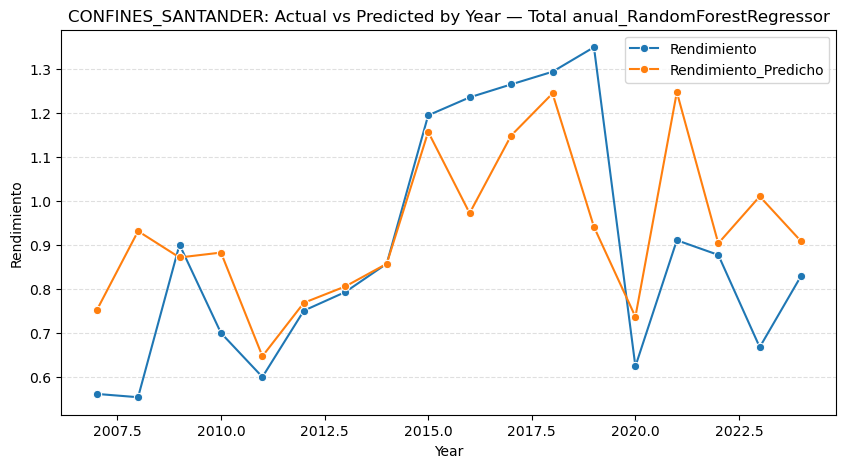

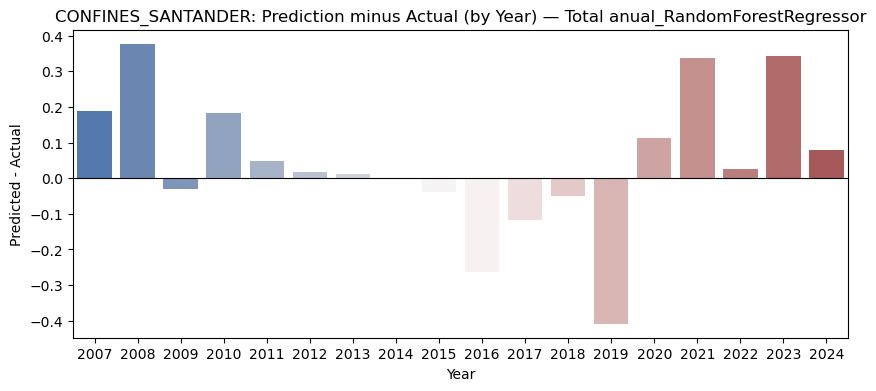

,Year,Rendimiento,Rendimiento_Predicho,diff
0,2007,0.560870,0.750437,0.189568
1,2008,0.553333,0.930677,0.377344
2,2009,0.899977,0.870850,-0.029127
3,2010,0.699301,0.881955,0.182654
4,2011,0.599301,0.646461,0.047160
5,2012,0.750000,0.767899,0.017899
6,2013,0.792331,0.805027,0.012696
7,2014,0.856743,0.856523,-0.000220
8,2015,1.193779,1.156196,-0.037583
9,2016,1.234609,0.971490,-0.263119


Processing CURITI_SANTANDER


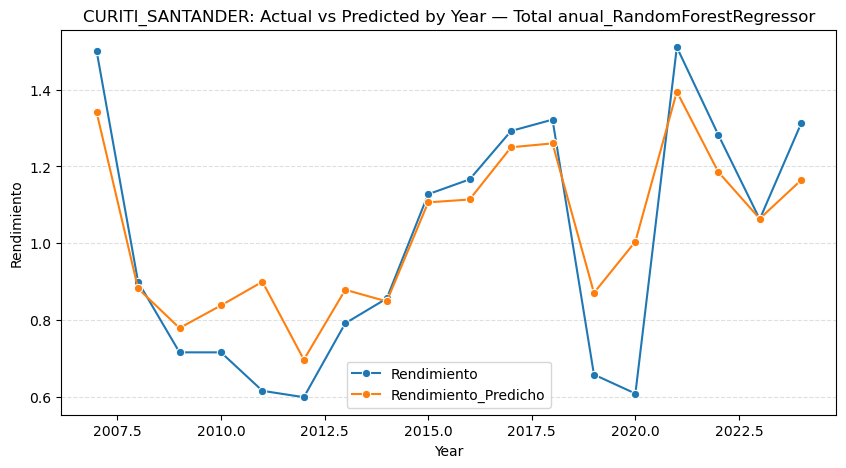

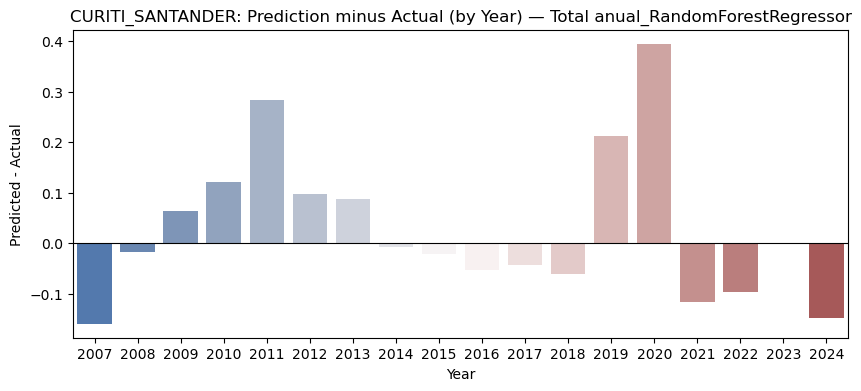

,Year,Rendimiento,Rendimiento_Predicho,diff
0,2007,1.500000,1.340651,-0.159349
1,2008,0.900000,0.882720,-0.017280
2,2009,0.716674,0.779909,0.063235
3,2010,0.716673,0.838604,0.121931
4,2011,0.616674,0.900262,0.283589
5,2012,0.600000,0.697640,0.097640
6,2013,0.792331,0.879398,0.087068
7,2014,0.856737,0.849161,-0.007576
8,2015,1.127801,1.106636,-0.021164
9,2016,1.166370,1.114094,-0.052275


Processing EL SOCORRO_SANTANDER


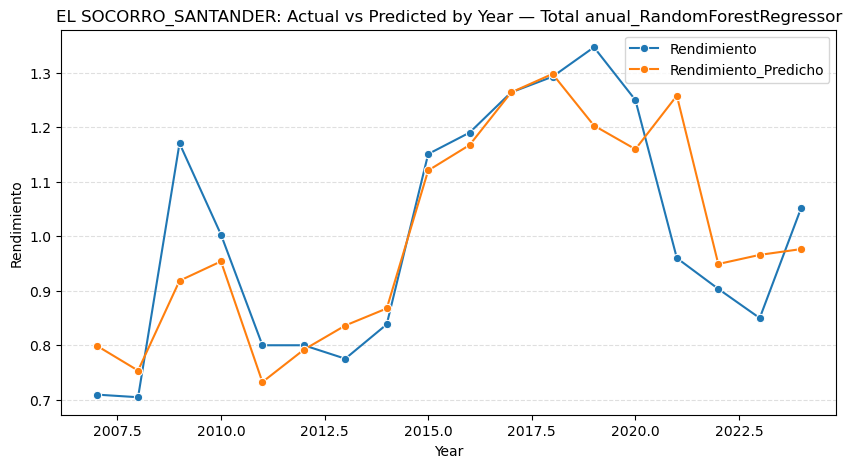

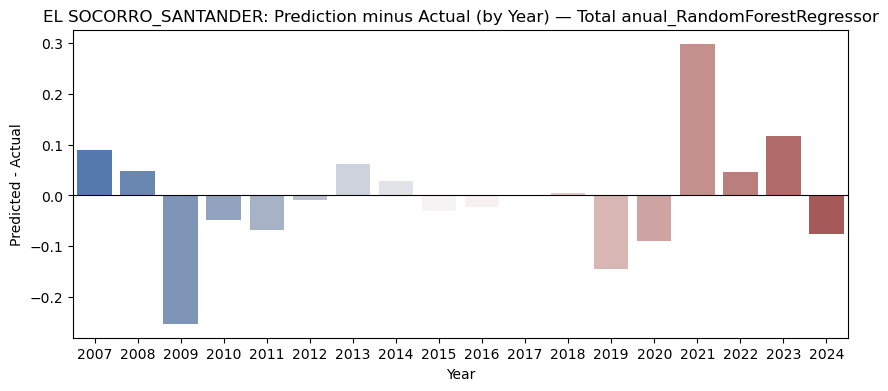

,Year,Rendimiento,Rendimiento_Predicho,diff
0,2007,0.709434,0.799323,0.089889
1,2008,0.704630,0.753530,0.048900
2,2009,1.170519,0.918365,-0.252153
3,2010,1.003164,0.953903,-0.049260
4,2011,0.800000,0.732453,-0.067547
5,2012,0.800000,0.791844,-0.008156
6,2013,0.775303,0.836241,0.060938
7,2014,0.838327,0.867539,0.029212
8,2015,1.150921,1.120716,-0.030205
9,2016,1.190282,1.167495,-0.022787


Processing GUADALUPE_SANTANDER


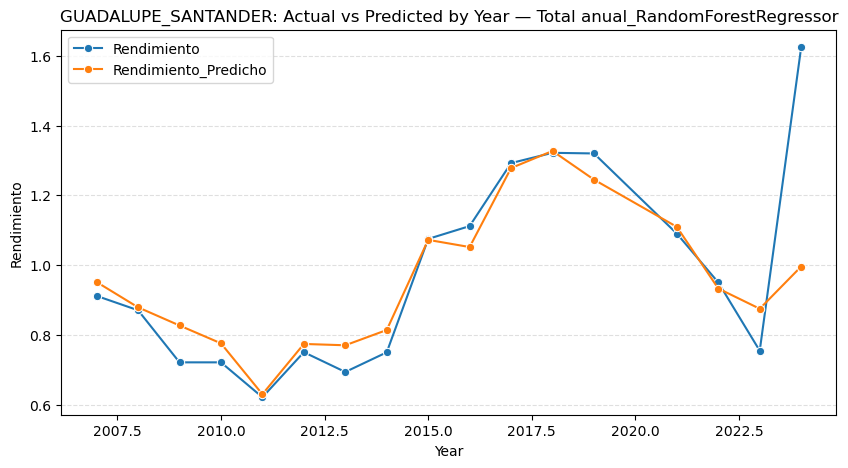

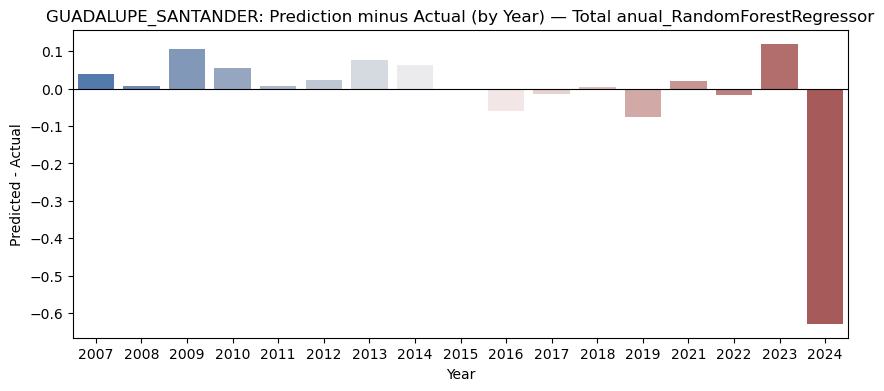

,Year,Rendimiento,Rendimiento_Predicho,diff
0,2007,0.911429,0.951140,0.039712
1,2008,0.870222,0.878676,0.008454
2,2009,0.720877,0.826562,0.105685
3,2010,0.720877,0.775403,0.054526
4,2011,0.620878,0.629440,0.008562
5,2012,0.750000,0.773652,0.023652
6,2013,0.693290,0.769825,0.076535
7,2014,0.749647,0.813619,0.063972
8,2015,1.074820,1.072112,-0.002708
9,2016,1.111584,1.051508,-0.060075


Processing GUAPOTA_SANTANDER


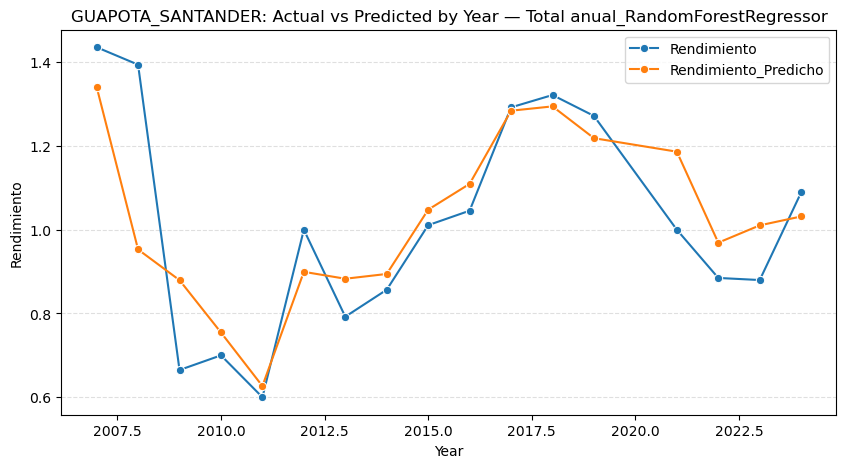

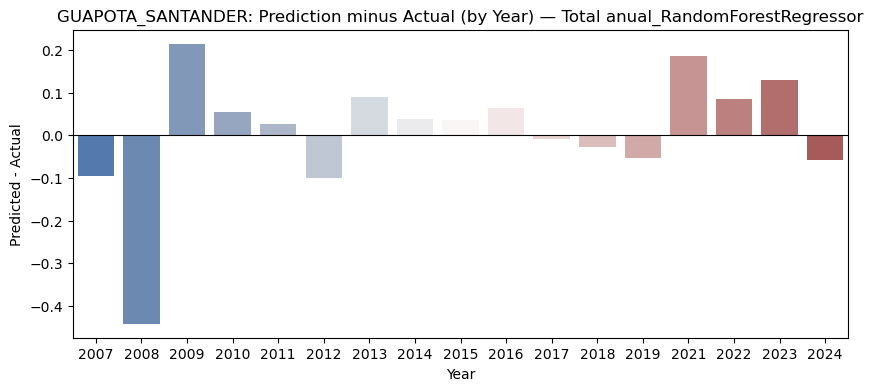

,Year,Rendimiento,Rendimiento_Predicho,diff
0,2007,1.435897,1.341204,-0.094693
1,2008,1.394231,0.952843,-0.441388
2,2009,0.664984,0.879572,0.214588
3,2010,0.700000,0.754586,0.054586
4,2011,0.600000,0.626676,0.026676
5,2012,1.000000,0.899465,-0.100535
6,2013,0.792330,0.882958,0.090628
7,2014,0.856738,0.894397,0.037659
8,2015,1.010899,1.047897,0.036998
9,2016,1.045471,1.109577,0.064107


Processing GUEPSA_SANTANDER


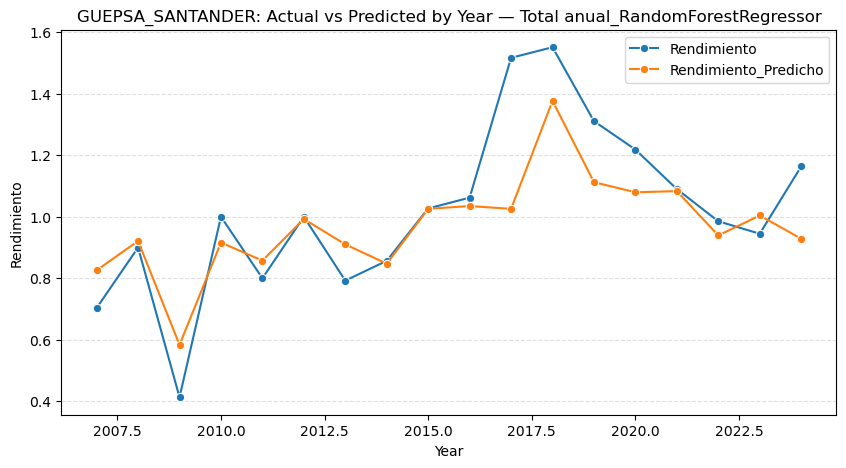

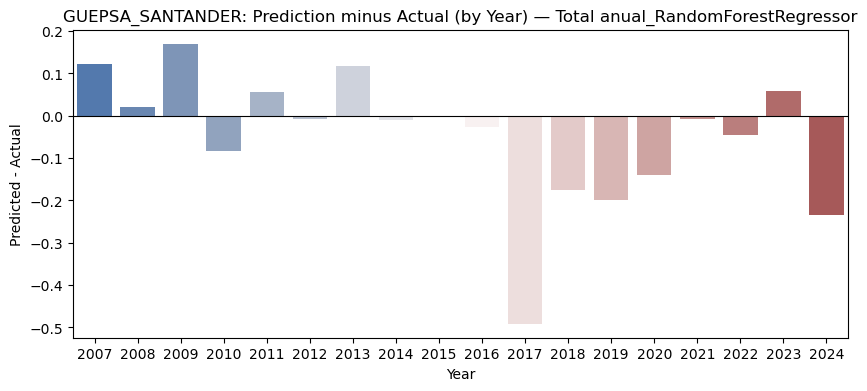

,Year,Rendimiento,Rendimiento_Predicho,diff
0,2007,0.703125,0.825804,0.122679
1,2008,0.900000,0.921300,0.021300
2,2009,0.413052,0.583355,0.170303
3,2010,1.000000,0.915991,-0.084009
4,2011,0.800000,0.857379,0.057379
5,2012,1.000000,0.992694,-0.007306
6,2013,0.792331,0.910023,0.117692
7,2014,0.856740,0.847389,-0.009351
8,2015,1.027011,1.025745,-0.001266
9,2016,1.062136,1.034857,-0.027279


Processing OCAMONTE_SANTANDER


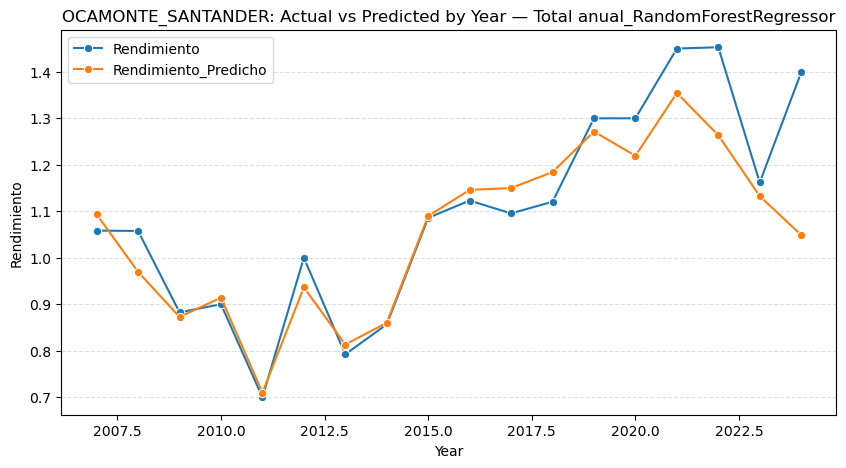

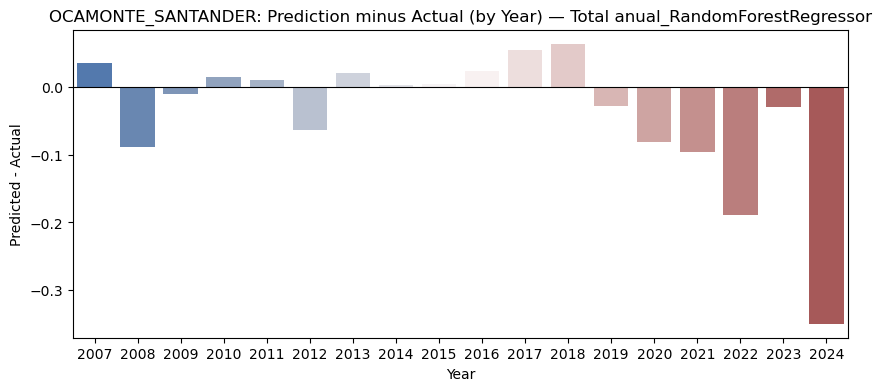

,Year,Rendimiento,Rendimiento_Predicho,diff
0,2007,1.058424,1.093359,0.034935
1,2008,1.057692,0.969707,-0.087986
2,2009,0.882493,0.872727,-0.009767
3,2010,0.900000,0.914161,0.014161
4,2011,0.700000,0.709790,0.009790
5,2012,1.000000,0.936210,-0.063790
6,2013,0.792331,0.813406,0.021075
7,2014,0.856740,0.860067,0.003327
8,2015,1.085850,1.089822,0.003972
9,2016,1.122984,1.146014,0.023030


Processing OIBA_SANTANDER


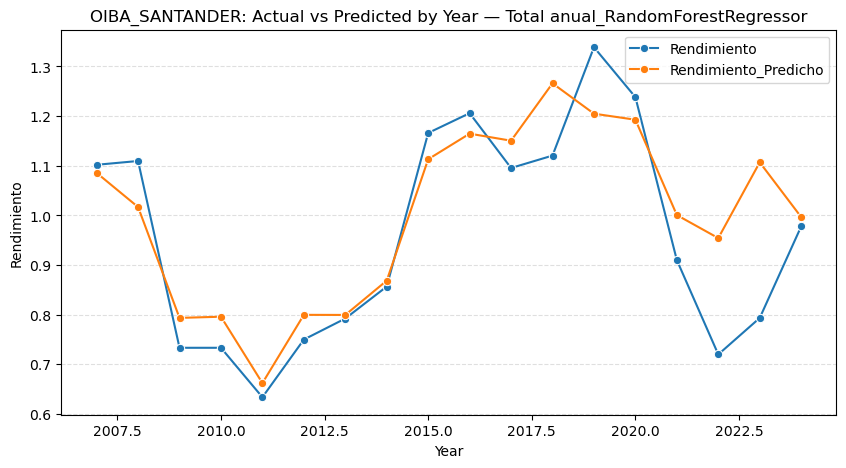

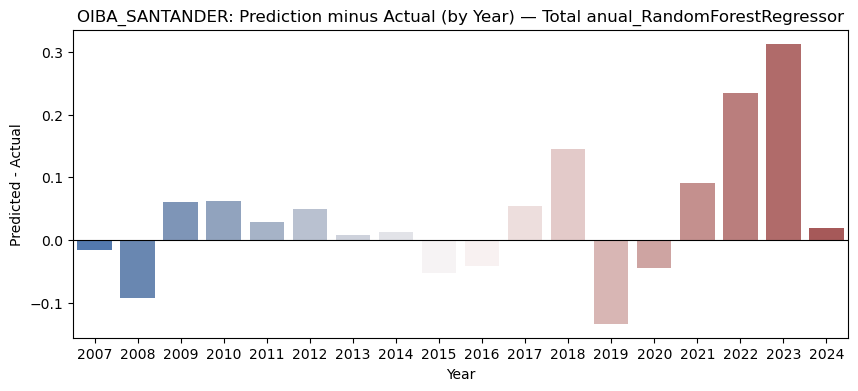

,Year,Rendimiento,Rendimiento_Predicho,diff
0,2007,1.101925,1.085663,-0.016262
1,2008,1.109573,1.016843,-0.092730
2,2009,0.733416,0.793617,0.060202
3,2010,0.733416,0.795992,0.062576
4,2011,0.633869,0.662309,0.028440
5,2012,0.750000,0.799754,0.049754
6,2013,0.792331,0.799558,0.007227
7,2014,0.856739,0.868662,0.011922
8,2015,1.165989,1.113108,-0.052881
9,2016,1.205867,1.164631,-0.041235


Processing PALMAS DEL SOCORRO_SANTANDER


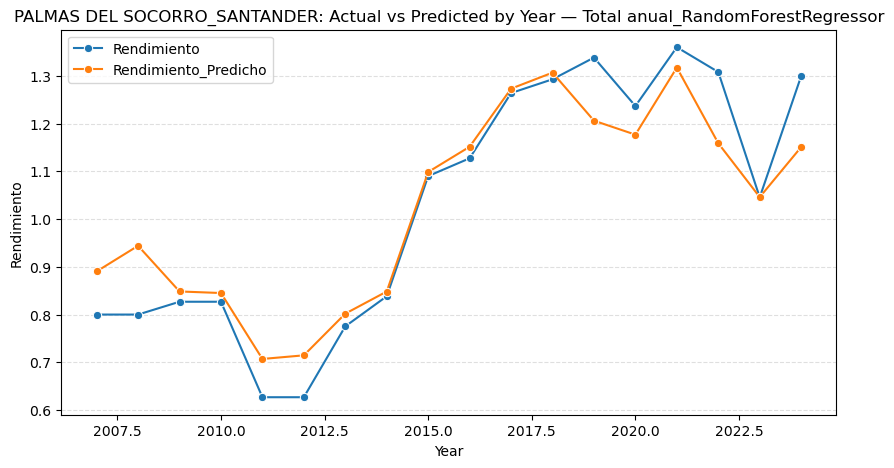

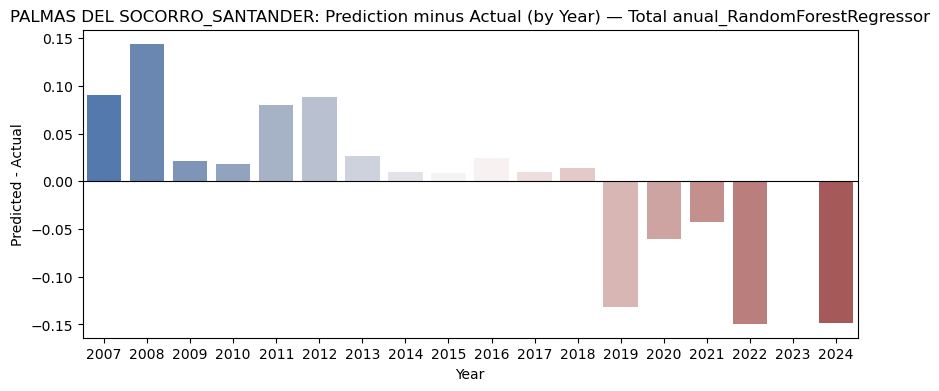

,Year,Rendimiento,Rendimiento_Predicho,diff
0,2007,0.800000,0.890354,0.090354
1,2008,0.800000,0.944062,0.144062
2,2009,0.826837,0.848402,0.021565
3,2010,0.826835,0.845093,0.018258
4,2011,0.626837,0.706998,0.080161
5,2012,0.626837,0.714573,0.087736
6,2013,0.775302,0.801892,0.026590
7,2014,0.838326,0.848263,0.009938
8,2015,1.090043,1.098573,0.008529
9,2016,1.127322,1.151509,0.024187


Processing PARAMO_SANTANDER


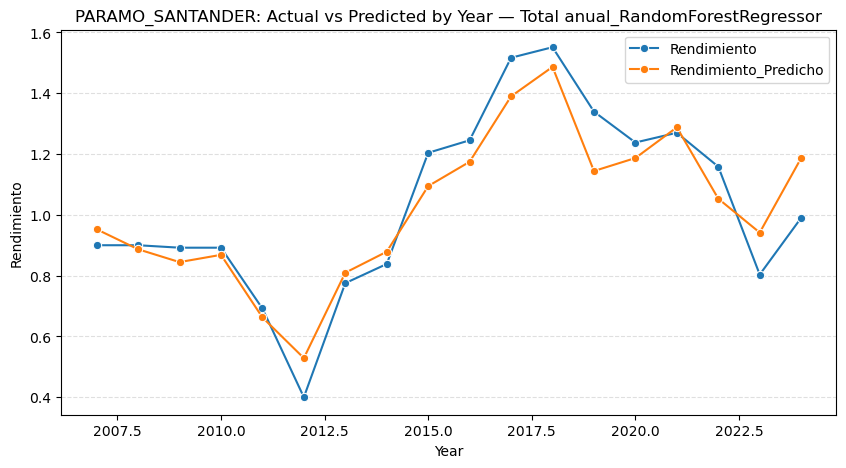

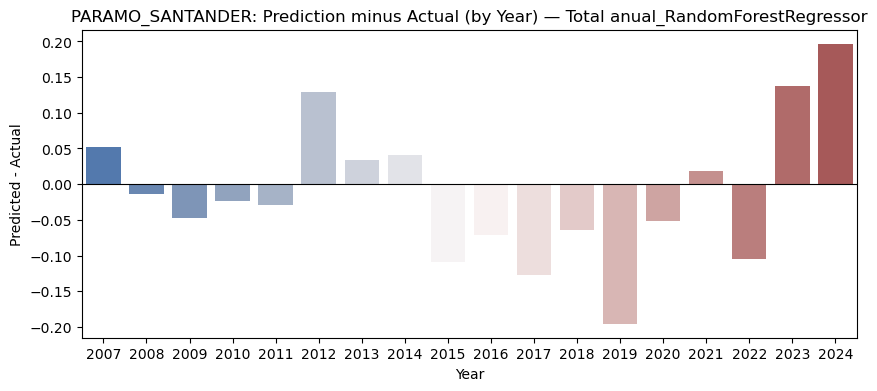

,Year,Rendimiento,Rendimiento_Predicho,diff
0,2007,0.900000,0.952520,0.052520
1,2008,0.900000,0.886787,-0.013213
2,2009,0.891894,0.844489,-0.047405
3,2010,0.891892,0.868363,-0.023529
4,2011,0.691894,0.662679,-0.029216
5,2012,0.400000,0.528711,0.128711
6,2013,0.775303,0.809628,0.034325
7,2014,0.838325,0.878699,0.040375
8,2015,1.204060,1.094479,-0.109581
9,2016,1.245233,1.174565,-0.070668


Processing PINCHOTE_SANTANDER


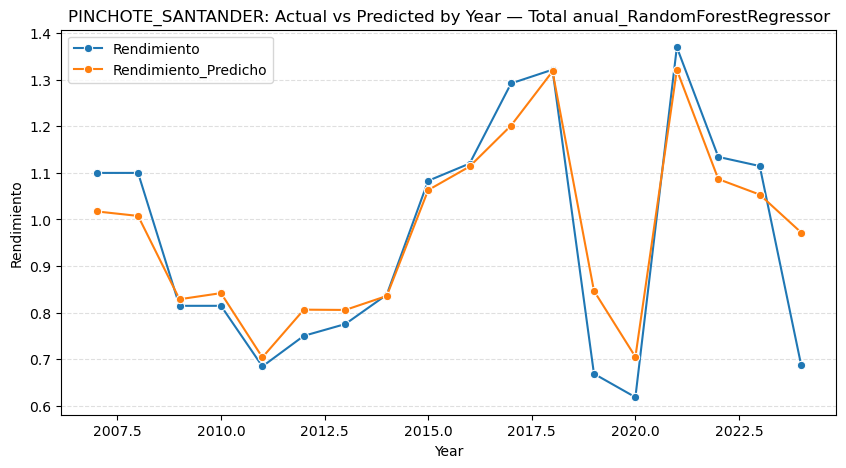

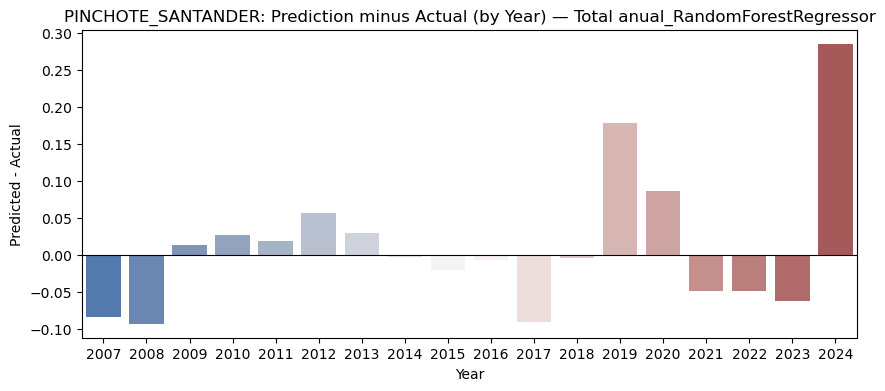

,Year,Rendimiento,Rendimiento_Predicho,diff
0,2007,1.100000,1.017276,-0.082724
1,2008,1.100000,1.007587,-0.092413
2,2009,0.814484,0.828572,0.014088
3,2010,0.814483,0.841767,0.027284
4,2011,0.684340,0.703736,0.019396
5,2012,0.750000,0.806219,0.056219
6,2013,0.775300,0.805613,0.030313
7,2014,0.838326,0.835641,-0.002686
8,2015,1.083099,1.063109,-0.019990
9,2016,1.120136,1.113768,-0.006368


Processing PUENTE NACIONAL_SANTANDER


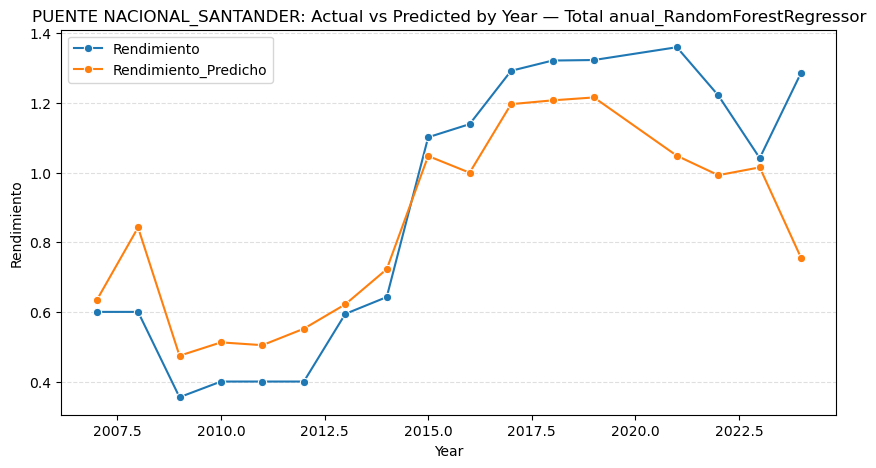

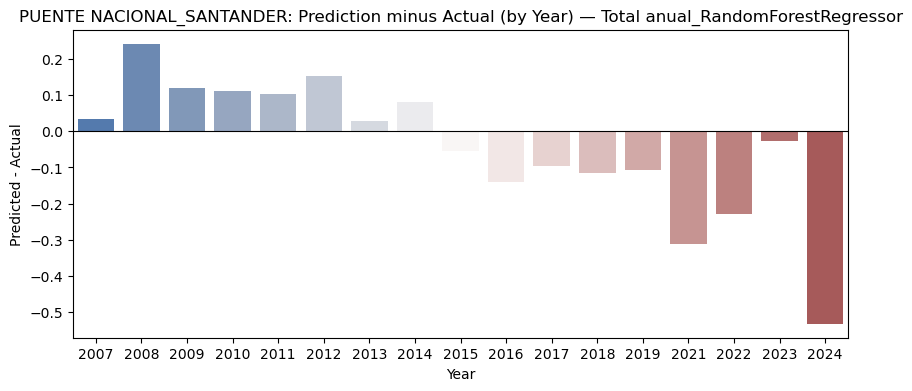

,Year,Rendimiento,Rendimiento_Predicho,diff
0,2007,0.600000,0.633033,0.033033
1,2008,0.600000,0.842353,0.242353
2,2009,0.354957,0.474095,0.119138
3,2010,0.400000,0.512442,0.112442
4,2011,0.400000,0.504425,0.104425
5,2012,0.400000,0.551703,0.151703
6,2013,0.594248,0.621688,0.027440
7,2014,0.642555,0.722584,0.080029
8,2015,1.101485,1.047620,-0.053865
9,2016,1.139157,0.999649,-0.139508


Processing SAN BENITO_SANTANDER


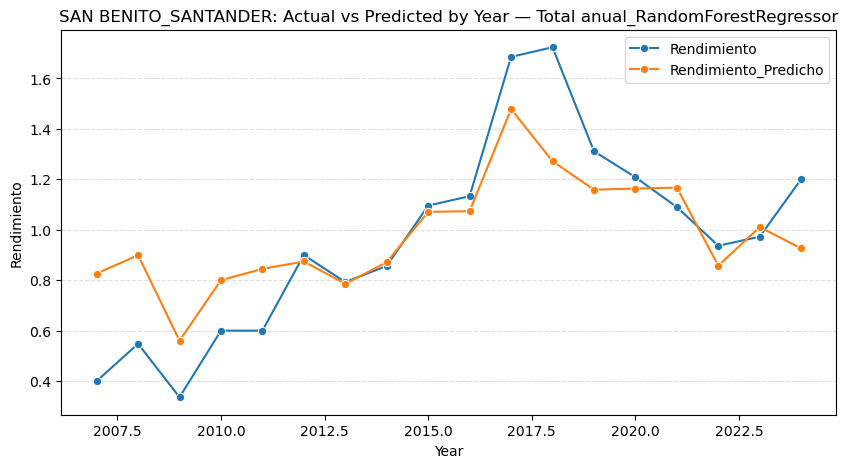

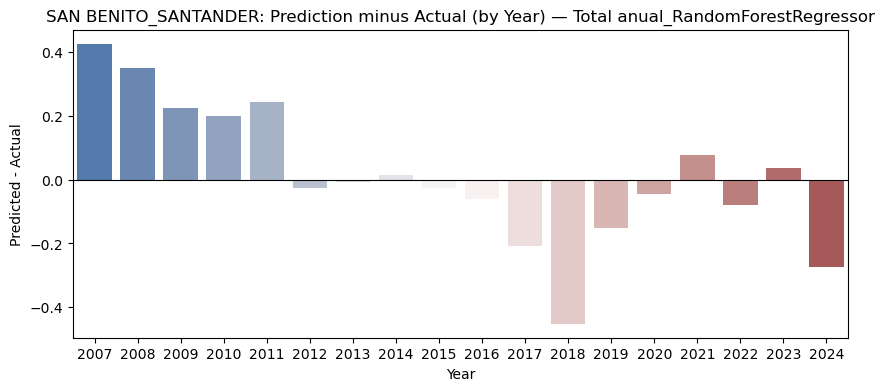

,Year,Rendimiento,Rendimiento_Predicho,diff
0,2007,0.400000,0.826609,0.426609
1,2008,0.547945,0.899187,0.351242
2,2009,0.336103,0.560368,0.224265
3,2010,0.600000,0.800273,0.200273
4,2011,0.600000,0.844848,0.244848
5,2012,0.900000,0.874259,-0.025741
6,2013,0.792329,0.785646,-0.006683
7,2014,0.856738,0.871387,0.014649
8,2015,1.095694,1.070984,-0.024709
9,2016,1.133167,1.073611,-0.059556


Processing SAN GIL_SANTANDER


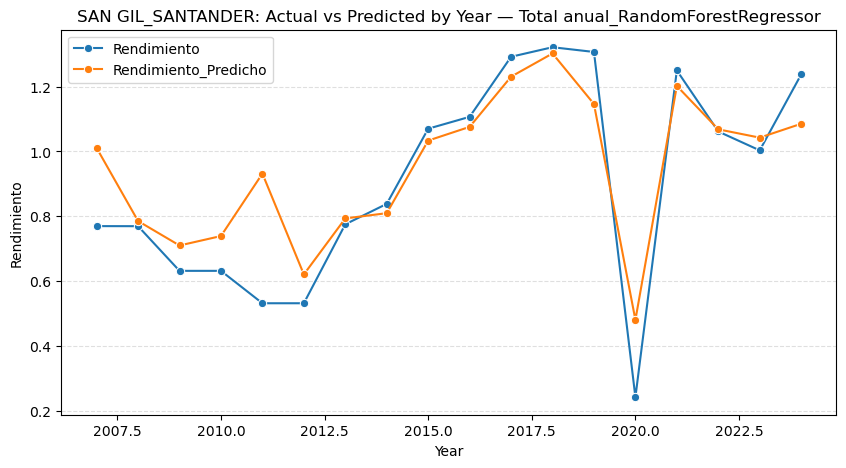

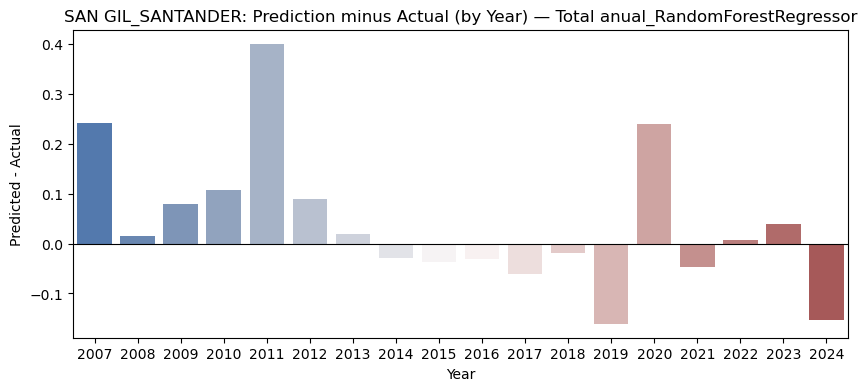

,Year,Rendimiento,Rendimiento_Predicho,diff
0,2007,0.769697,1.010864,0.241167
1,2008,0.769461,0.785316,0.015855
2,2009,0.631650,0.709930,0.078280
3,2010,0.631647,0.739044,0.107397
4,2011,0.531651,0.931724,0.400073
5,2012,0.531651,0.620601,0.088950
6,2013,0.775301,0.793409,0.018108
7,2014,0.838325,0.809649,-0.028677
8,2015,1.070270,1.033629,-0.036640
9,2016,1.106871,1.075933,-0.030938


Processing SUAITA_SANTANDER


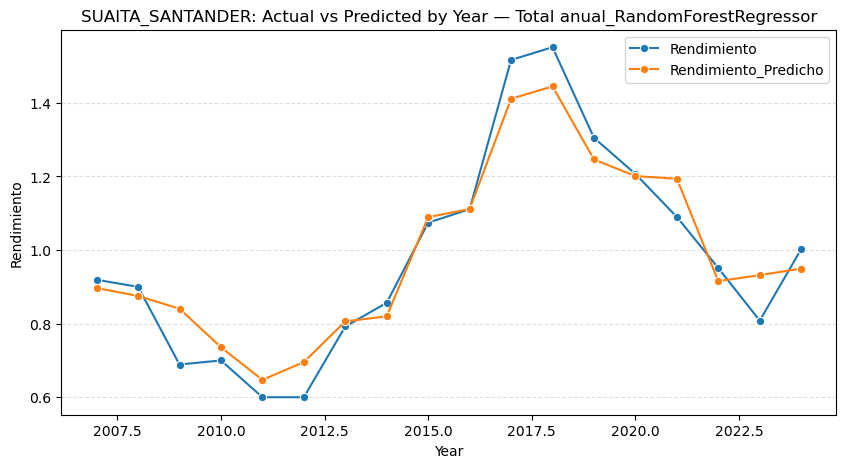

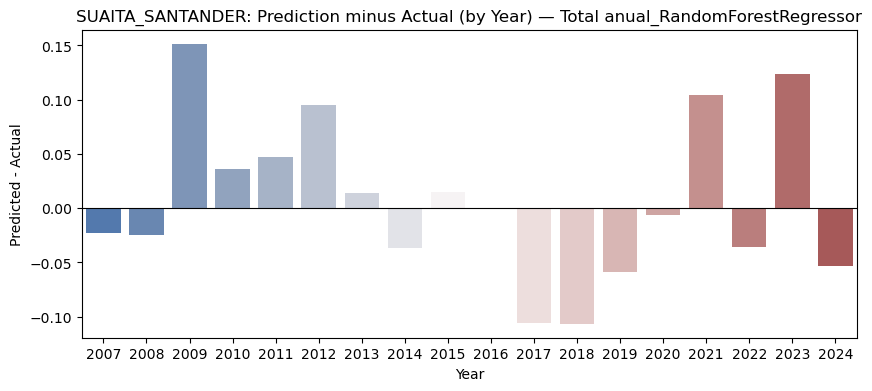

,Year,Rendimiento,Rendimiento_Predicho,diff
0,2007,0.919328,0.896824,-0.022504
1,2008,0.900000,0.875353,-0.024647
2,2009,0.688915,0.840532,0.151618
3,2010,0.700000,0.735840,0.035840
4,2011,0.599997,0.647176,0.047179
5,2012,0.600000,0.695536,0.095536
6,2013,0.792331,0.805994,0.013663
7,2014,0.856739,0.819939,-0.036801
8,2015,1.074465,1.089451,0.014986
9,2016,1.111215,1.111644,0.000429


Processing VALLE DE SAN JOSE_SANTANDER


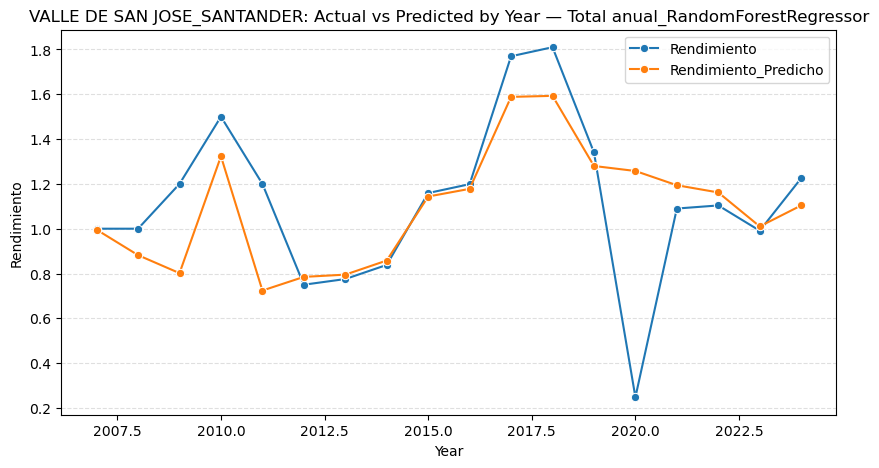

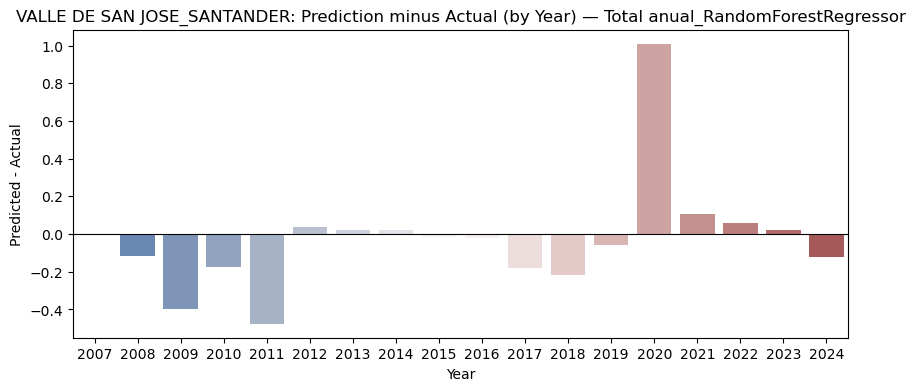

,Year,Rendimiento,Rendimiento_Predicho,diff
0,2007,1.000000,0.995544,-0.004456
1,2008,1.000000,0.881893,-0.118107
2,2009,1.200000,0.801644,-0.398356
3,2010,1.500000,1.323050,-0.176950
4,2011,1.200000,0.723983,-0.476016
5,2012,0.750000,0.784962,0.034962
6,2013,0.775303,0.794952,0.019649
7,2014,0.838327,0.858019,0.019692
8,2015,1.159141,1.143653,-0.015488
9,2016,1.198779,1.177834,-0.020946


In [106]:
plot_actual_vs_predicted('Total anual_RandomForestRegressor')

### Total de informacion anual + Total anual_LinearRegression	

Text(0, 0.5, 'Rendimiento Predicho')

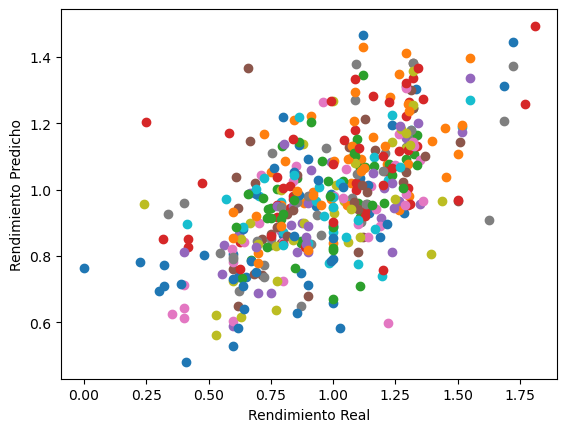

In [107]:
df_plot = backtest_results['Total anual_LinearRegression'].copy()
df_plot.groupby('Mpio').apply(lambda x: plt.scatter(x['Rendimiento'], x['Rendimiento_Predicho'], label=x.name))
plt.xlabel('Rendimiento Real')
plt.ylabel('Rendimiento Predicho')

In [108]:
df_plot = backtest_results['Total anual_LinearRegression'].copy()
df_plot['Error'] = df_plot['Rendimiento'] - df_plot['Rendimiento_Predicho']
df_plot['Abs_Error'] = df_plot['Error'].abs()
pred_error_mpio = df_plot.groupby('Mpio').mean()[['Error', 'Abs_Error', 'Rendimiento', 'Rendimiento_Predicho']]
pred_error_mpio.sort_values(by='Abs_Error', ascending=True, inplace=True)
pred_error_mpio

,Error,Abs_Error,Rendimiento,Rendimiento_Predicho
Mpio,,,,
CHARALA_SANTANDER,0.007194,0.128233,1.015501,1.008306
OCAMONTE_SANTANDER,0.026440,0.142906,1.096438,1.069998
SUAITA_SANTANDER,-0.059387,0.143149,0.981958,1.041345
SAN GIL_SANTANDER,0.026651,0.151512,0.909561,0.882911
GUEPSA_SANTANDER,0.016091,0.153207,1.018649,1.002557
PALMAS DEL SOCORRO_SANTANDER,0.004784,0.153358,1.026859,1.022075
EL SOCORRO_SANTANDER,-0.010897,0.155050,1.003430,1.014327
GUADALUPE_SANTANDER,0.039117,0.165077,0.975065,0.935948
PARAMO_SANTANDER,0.021435,0.167976,1.033686,1.012251


Processing MONIQUIRA_BOYACA


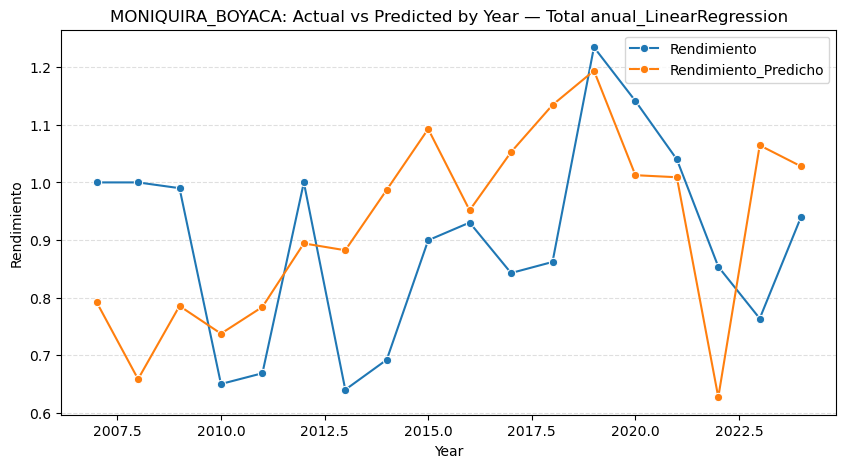

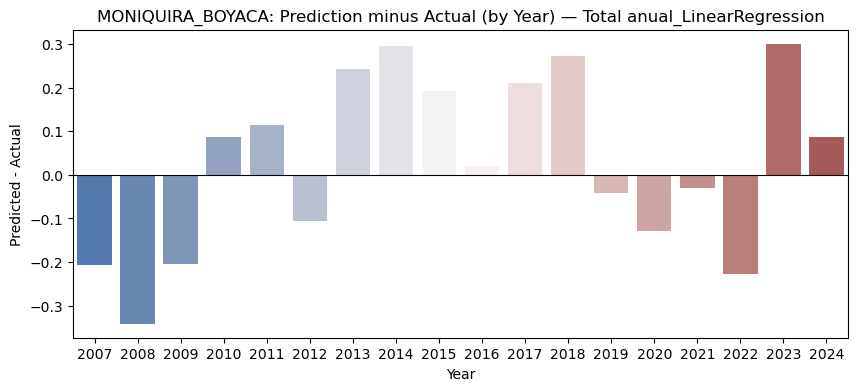

,Year,Rendimiento,Rendimiento_Predicho,diff
0,2007,1.000000,0.792095,-0.207905
1,2008,1.000000,0.658468,-0.341532
2,2009,0.990000,0.785493,-0.204507
3,2010,0.650000,0.737445,0.087445
4,2011,0.668693,0.783825,0.115132
5,2012,1.000000,0.894106,-0.105894
6,2013,0.640093,0.882190,0.242097
7,2014,0.692126,0.987132,0.295006
8,2015,0.899531,1.092741,0.193210
9,2016,0.930295,0.951624,0.021329


Processing SAN JOSE DE PARE_BOYACA


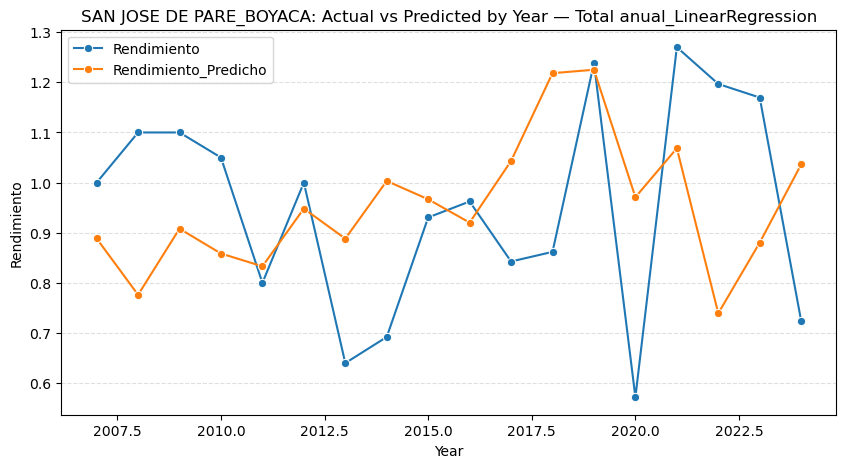

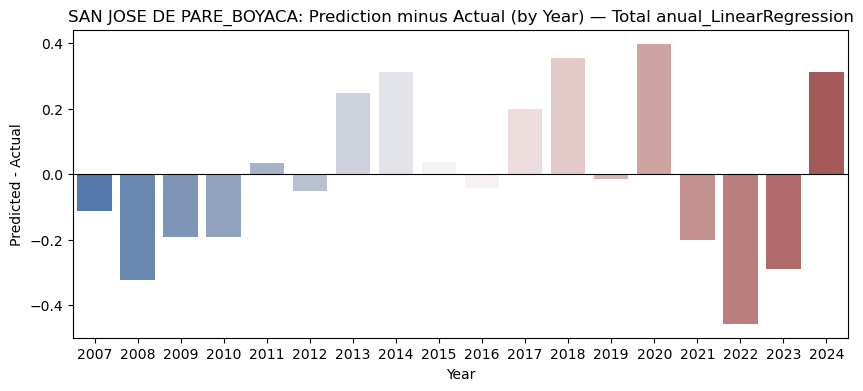

,Year,Rendimiento,Rendimiento_Predicho,diff
0,2007,1.000000,0.888635,-0.111365
1,2008,1.100000,0.776237,-0.323763
2,2009,1.100000,0.908095,-0.191905
3,2010,1.050000,0.858596,-0.191404
4,2011,0.800000,0.833049,0.033049
5,2012,1.000000,0.948133,-0.051867
6,2013,0.640093,0.888250,0.248157
7,2014,0.692126,1.003303,0.311177
8,2015,0.930519,0.966737,0.036218
9,2016,0.962342,0.920280,-0.042062


Processing SANTANA_BOYACA


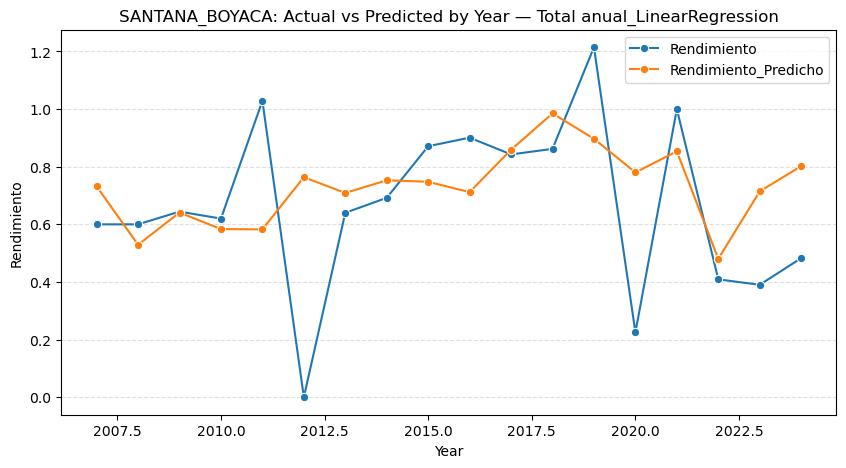

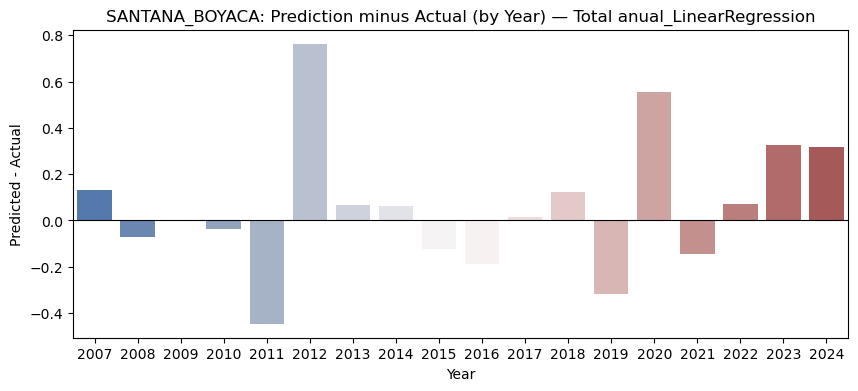

,Year,Rendimiento,Rendimiento_Predicho,diff
0,2007,0.600000,0.731821,0.131821
1,2008,0.600000,0.529116,-0.070884
2,2009,0.644185,0.640967,-0.003218
3,2010,0.620000,0.583573,-0.036427
4,2011,1.028571,0.582561,-0.446011
5,2012,0.000000,0.763678,0.763678
6,2013,0.640092,0.709016,0.068924
7,2014,0.692127,0.752910,0.060783
8,2015,0.871101,0.747720,-0.123381
9,2016,0.900895,0.711805,-0.189090


Processing TOGUI_BOYACA


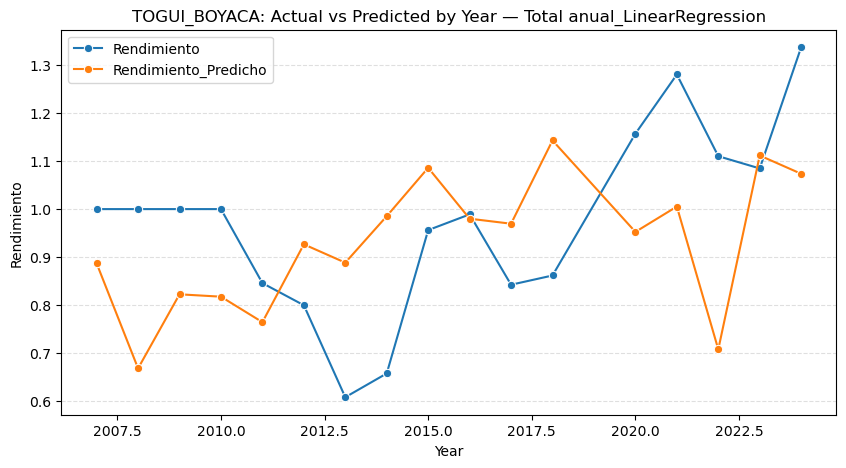

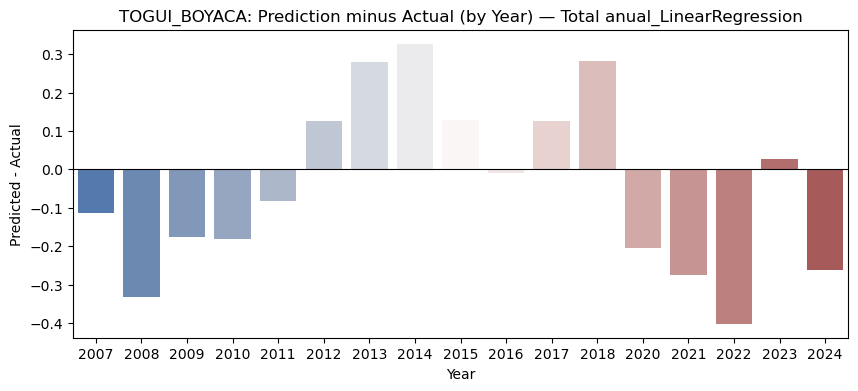

,Year,Rendimiento,Rendimiento_Predicho,diff
0,2007,1.000000,0.887135,-0.112865
1,2008,1.000000,0.668658,-0.331342
2,2009,1.000000,0.822737,-0.177263
3,2010,1.000000,0.817811,-0.182189
4,2011,0.846037,0.764778,-0.081259
5,2012,0.800000,0.926745,0.126745
6,2013,0.608660,0.888576,0.279916
7,2014,0.658138,0.985302,0.327164
8,2015,0.956296,1.085929,0.129633
9,2016,0.989003,0.980032,-0.008972


Processing AGUADA_SANTANDER


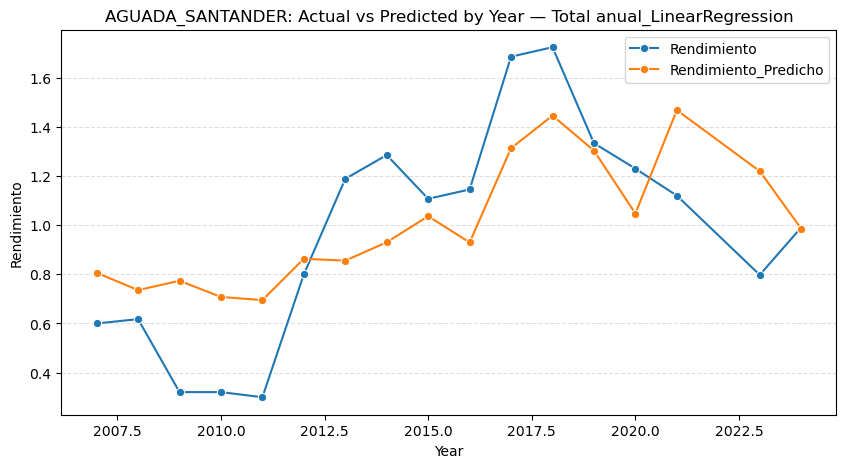

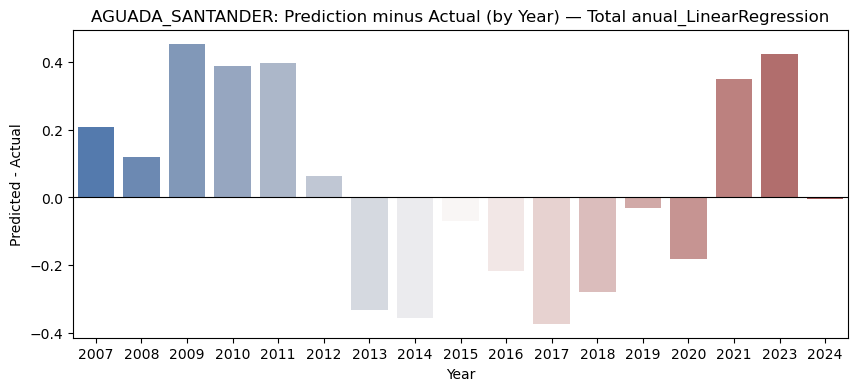

,Year,Rendimiento,Rendimiento_Predicho,diff
0,2007,0.600000,0.806064,0.206064
1,2008,0.617647,0.735720,0.118073
2,2009,0.320836,0.773769,0.452933
3,2010,0.320836,0.707911,0.387075
4,2011,0.300000,0.695003,0.395003
5,2012,0.800000,0.863171,0.063171
6,2013,1.188496,0.855676,-0.332819
7,2014,1.285110,0.930263,-0.354846
8,2015,1.107177,1.036502,-0.070676
9,2016,1.145044,0.929539,-0.215505


Processing BARBOSA_SANTANDER


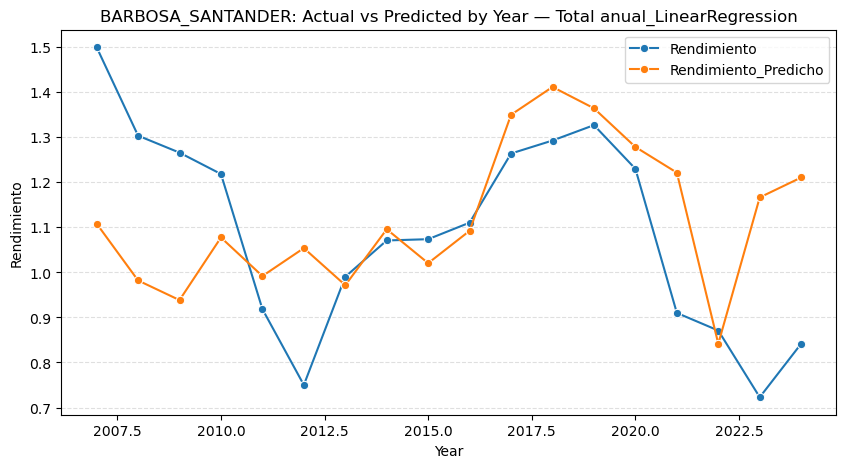

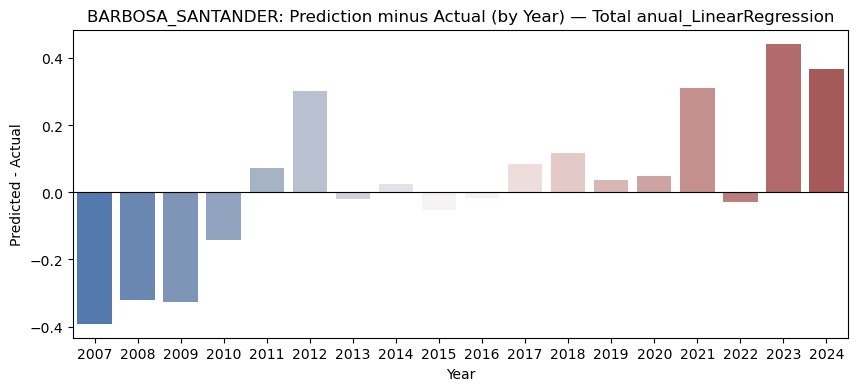

,Year,Rendimiento,Rendimiento_Predicho,diff
0,2007,1.500000,1.108300,-0.391700
1,2008,1.303614,0.982086,-0.321529
2,2009,1.265922,0.938480,-0.327442
3,2010,1.218450,1.077487,-0.140963
4,2011,0.918451,0.991898,0.073447
5,2012,0.750000,1.053908,0.303908
6,2013,0.990413,0.971557,-0.018856
7,2014,1.070925,1.095795,0.024870
8,2015,1.073733,1.020493,-0.053240
9,2016,1.110455,1.092364,-0.018091


Processing CHARALA_SANTANDER


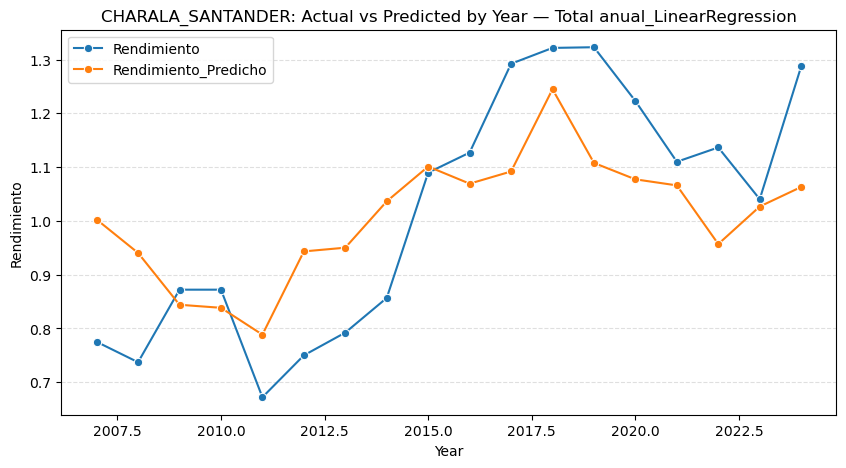

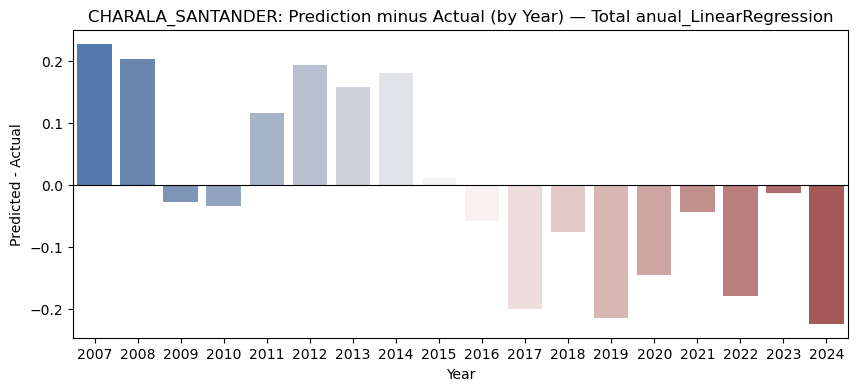

,Year,Rendimiento,Rendimiento_Predicho,diff
0,2007,0.775172,1.002631,0.227459
1,2008,0.737206,0.940484,0.203278
2,2009,0.872147,0.844084,-0.028063
3,2010,0.872146,0.838432,-0.033714
4,2011,0.672147,0.788482,0.116335
5,2012,0.750000,0.943296,0.193296
6,2013,0.792330,0.950229,0.157899
7,2014,0.856739,1.036421,0.179681
8,2015,1.089778,1.101179,0.011401
9,2016,1.127056,1.069288,-0.057768


Processing CHIPATA_SANTANDER


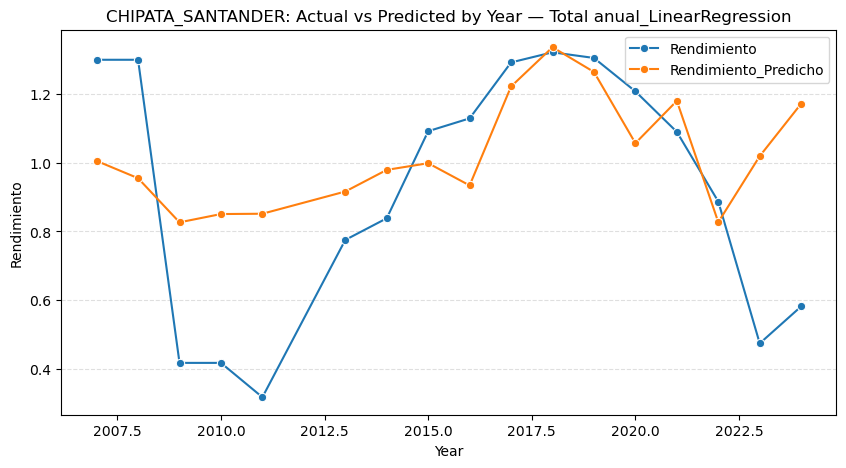

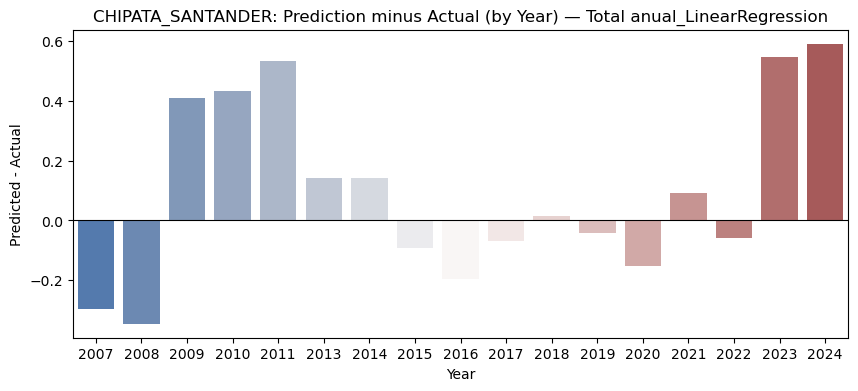

,Year,Rendimiento,Rendimiento_Predicho,diff
0,2007,1.300000,1.005409,-0.294591
1,2008,1.300000,0.955066,-0.344934
2,2009,0.417200,0.826532,0.409332
3,2010,0.417199,0.850678,0.433479
4,2011,0.317201,0.851574,0.534373
5,2013,0.775302,0.916271,0.140969
6,2014,0.838326,0.979301,0.140975
7,2015,1.091972,0.998770,-0.093203
8,2016,1.129318,0.934008,-0.195310
9,2017,1.292260,1.222153,-0.070107


Processing CONFINES_SANTANDER


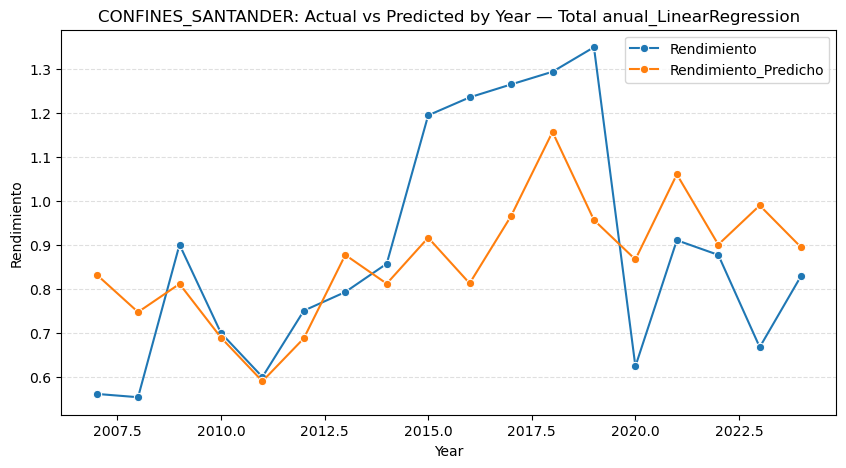

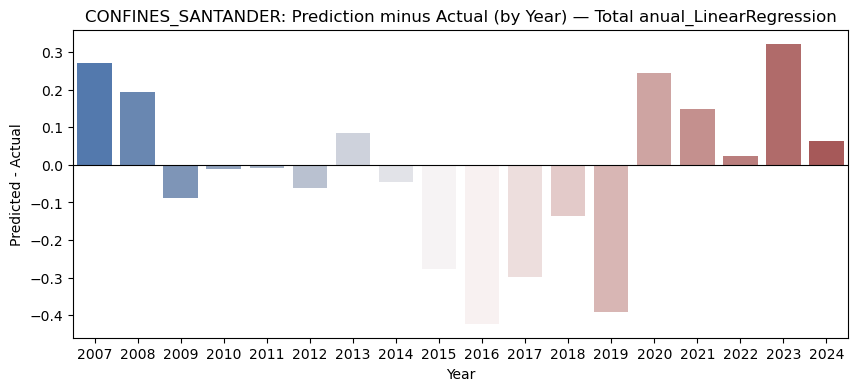

,Year,Rendimiento,Rendimiento_Predicho,diff
0,2007,0.560870,0.831936,0.271066
1,2008,0.553333,0.746772,0.193438
2,2009,0.899977,0.810768,-0.089209
3,2010,0.699301,0.688910,-0.010390
4,2011,0.599301,0.589678,-0.009623
5,2012,0.750000,0.687224,-0.062776
6,2013,0.792331,0.876624,0.084293
7,2014,0.856743,0.811342,-0.045401
8,2015,1.193779,0.915808,-0.277971
9,2016,1.234609,0.812022,-0.422587


Processing CURITI_SANTANDER


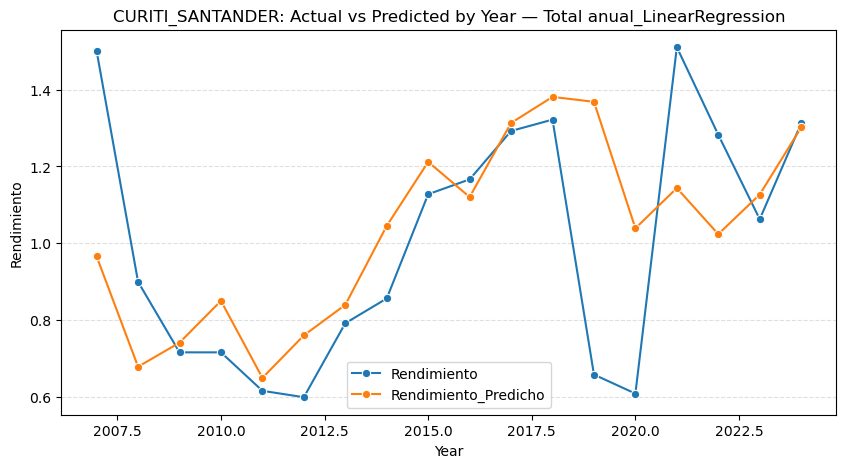

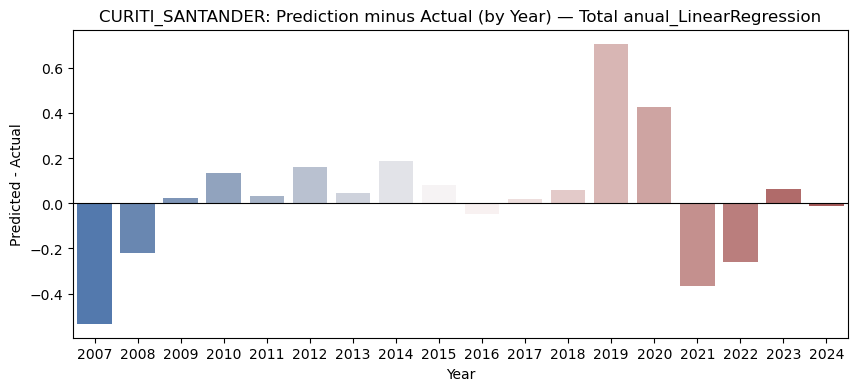

,Year,Rendimiento,Rendimiento_Predicho,diff
0,2007,1.500000,0.965929,-0.534071
1,2008,0.900000,0.679313,-0.220687
2,2009,0.716674,0.741842,0.025168
3,2010,0.716673,0.850588,0.133915
4,2011,0.616674,0.650334,0.033661
5,2012,0.600000,0.760741,0.160741
6,2013,0.792331,0.840191,0.047860
7,2014,0.856737,1.045548,0.188810
8,2015,1.127801,1.211919,0.084119
9,2016,1.166370,1.120496,-0.045874


Processing EL SOCORRO_SANTANDER


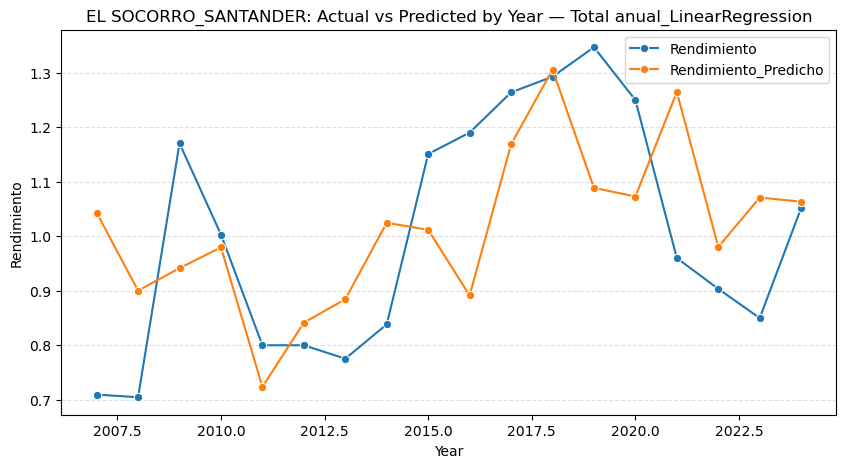

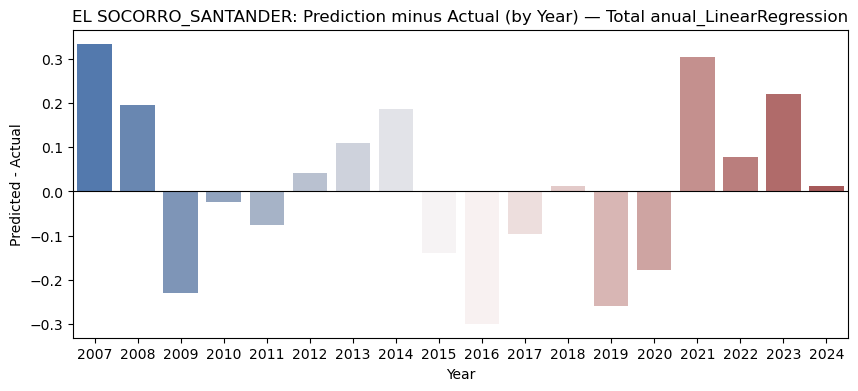

,Year,Rendimiento,Rendimiento_Predicho,diff
0,2007,0.709434,1.043190,0.333756
1,2008,0.704630,0.900209,0.195580
2,2009,1.170519,0.941480,-0.229038
3,2010,1.003164,0.979662,-0.023502
4,2011,0.800000,0.723626,-0.076374
5,2012,0.800000,0.841371,0.041371
6,2013,0.775303,0.884485,0.109182
7,2014,0.838327,1.024797,0.186470
8,2015,1.150921,1.011854,-0.139067
9,2016,1.190282,0.891354,-0.298928


Processing GUADALUPE_SANTANDER


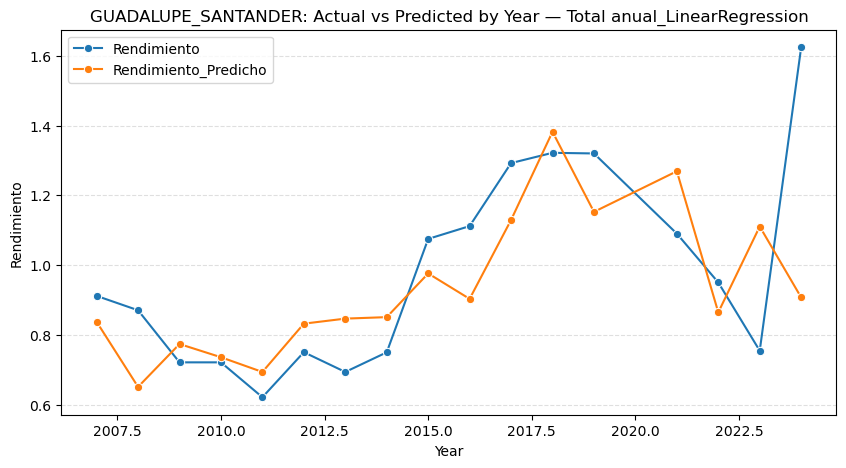

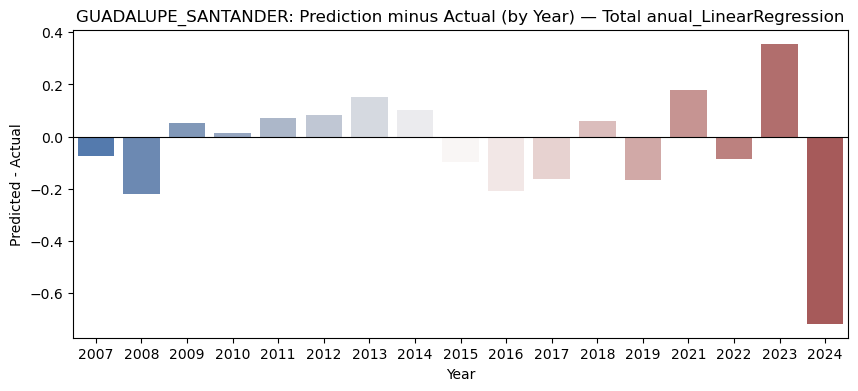

,Year,Rendimiento,Rendimiento_Predicho,diff
0,2007,0.911429,0.837102,-0.074327
1,2008,0.870222,0.650462,-0.219760
2,2009,0.720877,0.773437,0.052560
3,2010,0.720877,0.735548,0.014672
4,2011,0.620878,0.693298,0.072420
5,2012,0.750000,0.831806,0.081806
6,2013,0.693290,0.846275,0.152986
7,2014,0.749647,0.850532,0.100885
8,2015,1.074820,0.975821,-0.098999
9,2016,1.111584,0.902906,-0.208678


Processing GUAPOTA_SANTANDER


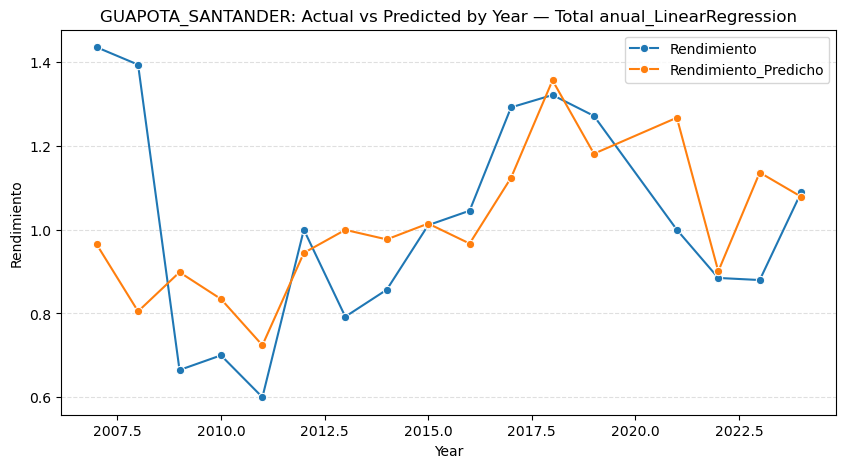

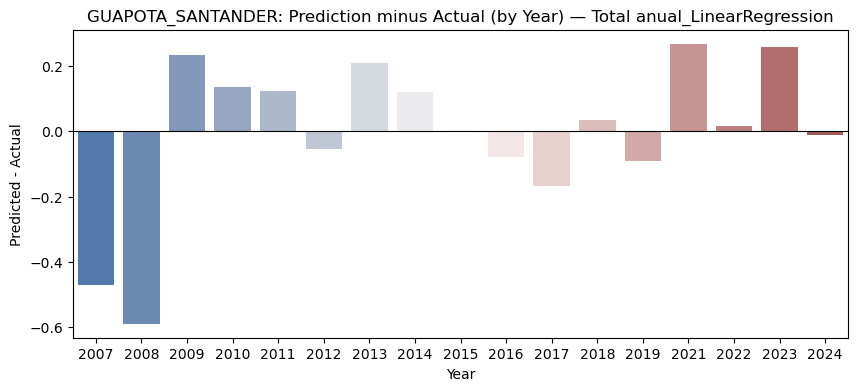

,Year,Rendimiento,Rendimiento_Predicho,diff
0,2007,1.435897,0.965151,-0.470747
1,2008,1.394231,0.804983,-0.589248
2,2009,0.664984,0.898575,0.233591
3,2010,0.700000,0.834533,0.134533
4,2011,0.600000,0.724102,0.124102
5,2012,1.000000,0.944693,-0.055307
6,2013,0.792330,0.999693,0.207363
7,2014,0.856738,0.976914,0.120175
8,2015,1.010899,1.014777,0.003878
9,2016,1.045471,0.966998,-0.078472


Processing GUEPSA_SANTANDER


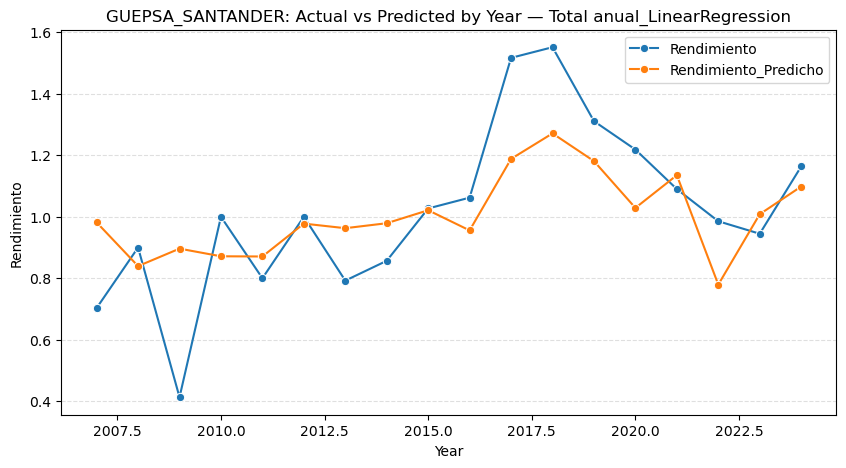

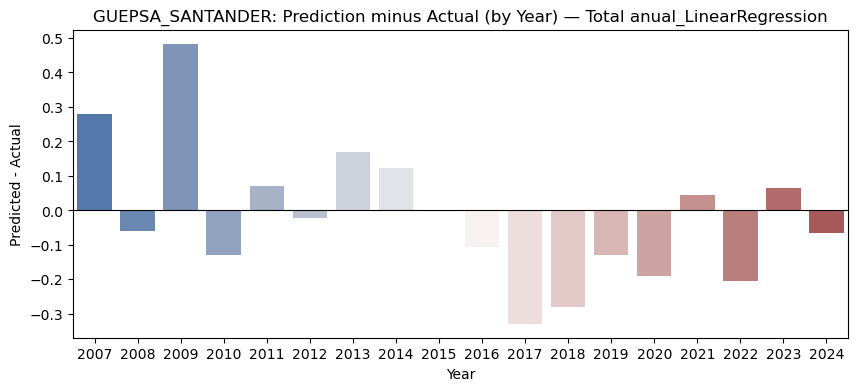

,Year,Rendimiento,Rendimiento_Predicho,diff
0,2007,0.703125,0.981636,0.278511
1,2008,0.900000,0.839444,-0.060556
2,2009,0.413052,0.896289,0.483237
3,2010,1.000000,0.871428,-0.128572
4,2011,0.800000,0.870765,0.070765
5,2012,1.000000,0.977693,-0.022307
6,2013,0.792331,0.962796,0.170465
7,2014,0.856740,0.978967,0.122227
8,2015,1.027011,1.021198,-0.005812
9,2016,1.062136,0.955590,-0.106547


Processing OCAMONTE_SANTANDER


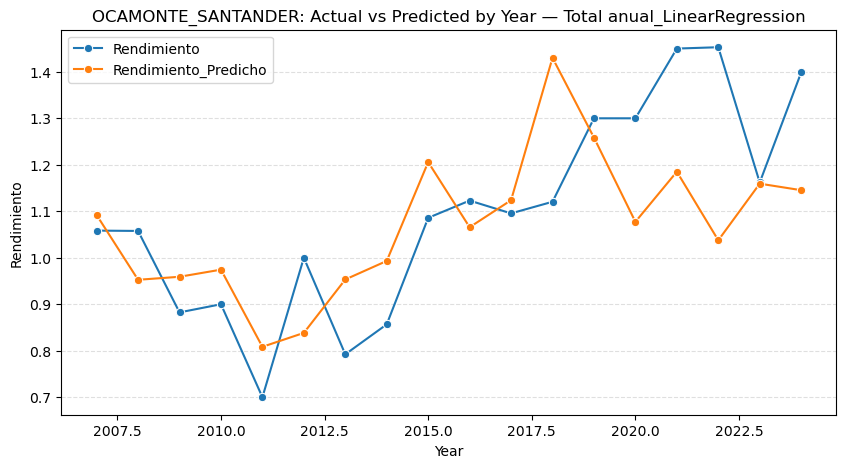

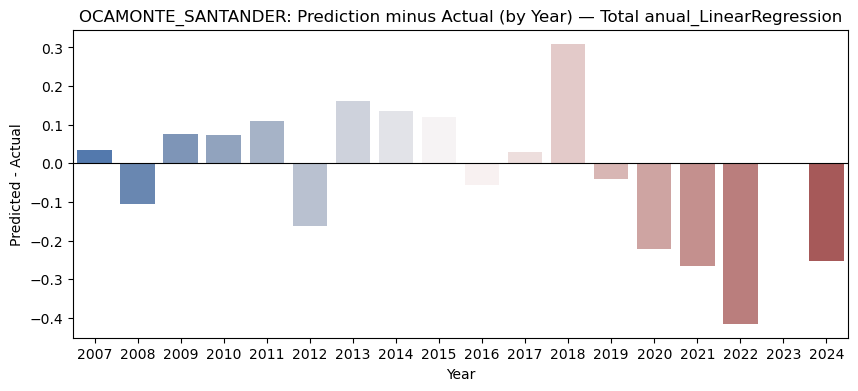

,Year,Rendimiento,Rendimiento_Predicho,diff
0,2007,1.058424,1.091953,0.033530
1,2008,1.057692,0.952616,-0.105077
2,2009,0.882493,0.959107,0.076614
3,2010,0.900000,0.974424,0.074424
4,2011,0.700000,0.808413,0.108413
5,2012,1.000000,0.838360,-0.161640
6,2013,0.792331,0.953284,0.160953
7,2014,0.856740,0.993147,0.136407
8,2015,1.085850,1.205780,0.119931
9,2016,1.122984,1.065668,-0.057317


Processing OIBA_SANTANDER


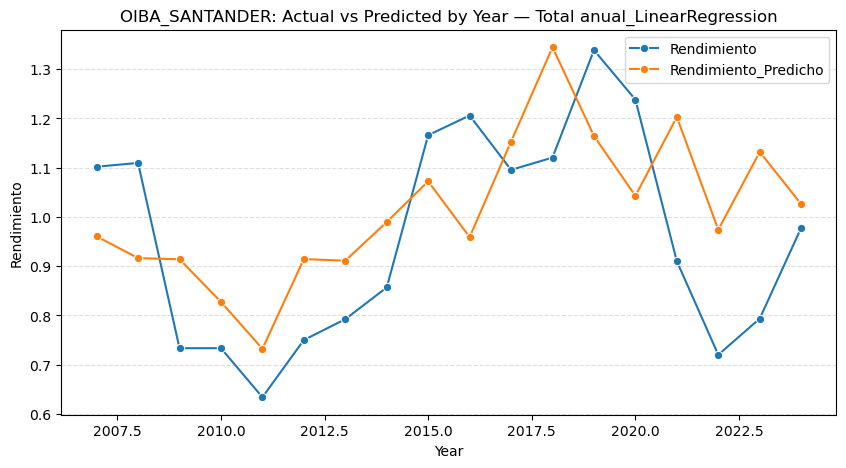

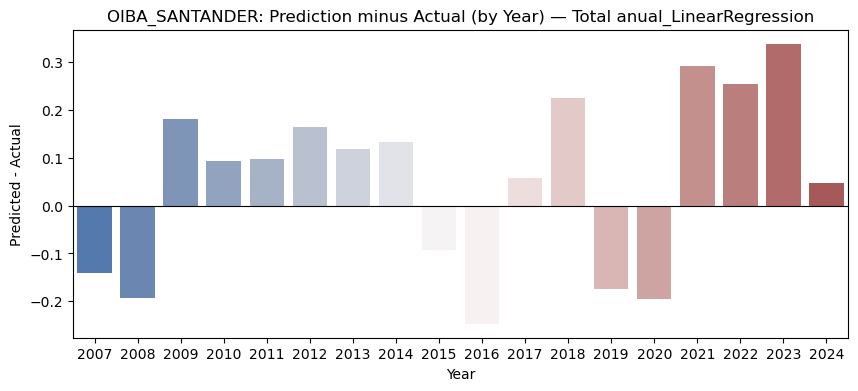

,Year,Rendimiento,Rendimiento_Predicho,diff
0,2007,1.101925,0.960451,-0.141474
1,2008,1.109573,0.916382,-0.193191
2,2009,0.733416,0.913930,0.180514
3,2010,0.733416,0.827509,0.094093
4,2011,0.633869,0.732191,0.098322
5,2012,0.750000,0.914399,0.164399
6,2013,0.792331,0.911036,0.118705
7,2014,0.856739,0.989619,0.132879
8,2015,1.165989,1.072236,-0.093754
9,2016,1.205867,0.958986,-0.246881


Processing PALMAS DEL SOCORRO_SANTANDER


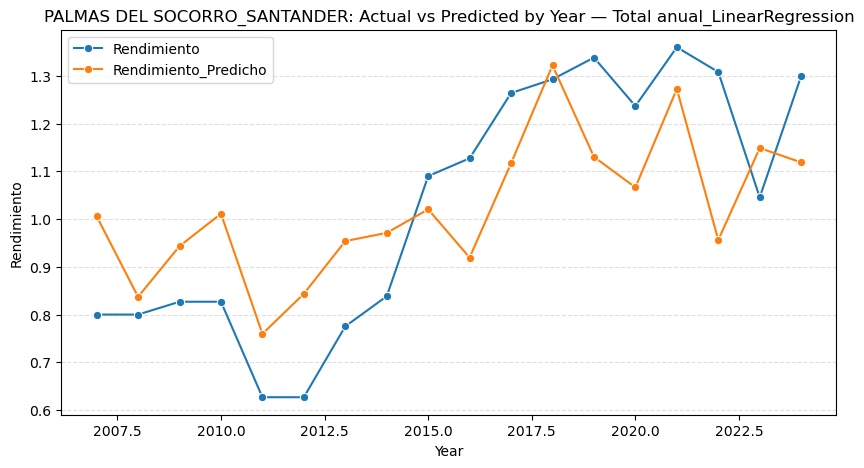

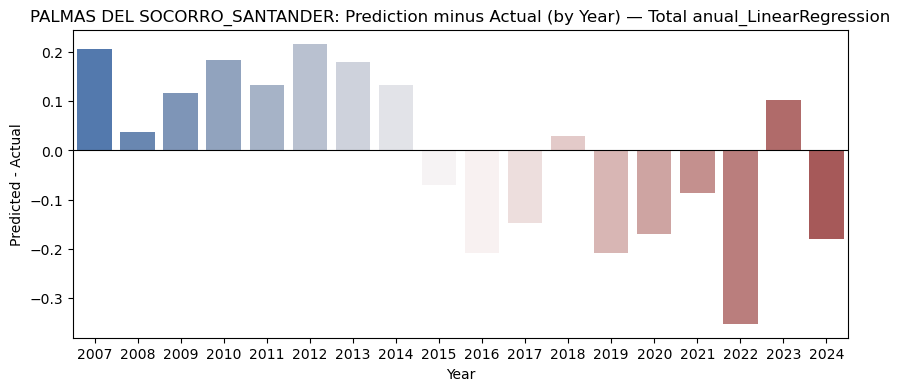

,Year,Rendimiento,Rendimiento_Predicho,diff
0,2007,0.800000,1.005959,0.205959
1,2008,0.800000,0.837190,0.037190
2,2009,0.826837,0.943278,0.116441
3,2010,0.826835,1.011209,0.184374
4,2011,0.626837,0.759561,0.132724
5,2012,0.626837,0.843475,0.216638
6,2013,0.775302,0.953885,0.178583
7,2014,0.838326,0.971089,0.132764
8,2015,1.090043,1.020423,-0.069620
9,2016,1.127322,0.919375,-0.207947


Processing PARAMO_SANTANDER


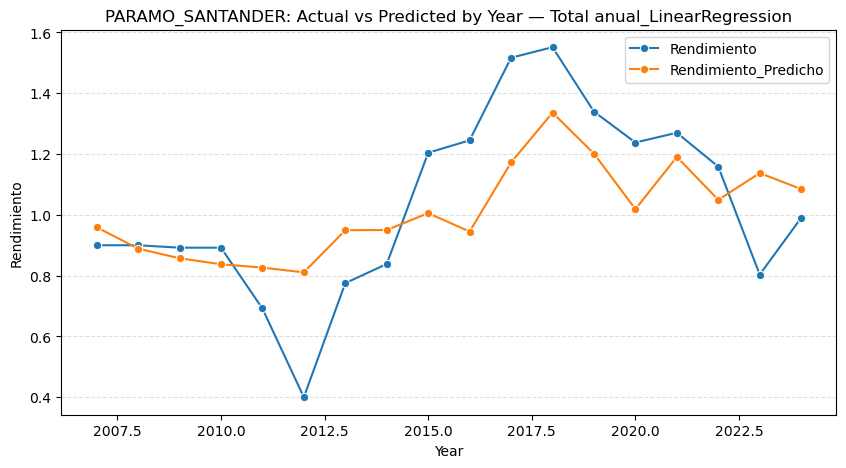

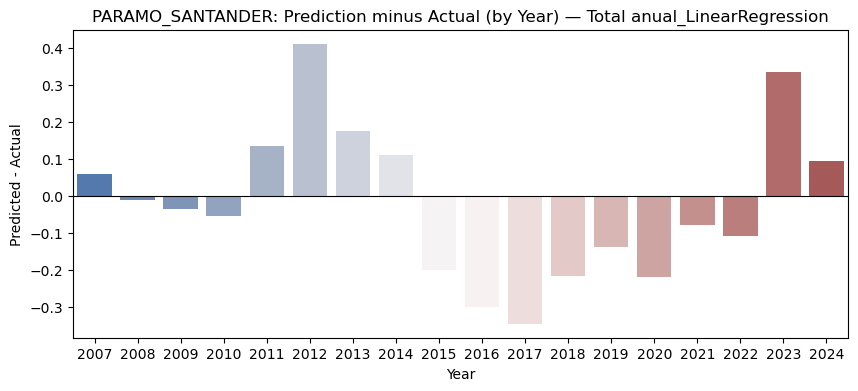

,Year,Rendimiento,Rendimiento_Predicho,diff
0,2007,0.900000,0.959189,0.059189
1,2008,0.900000,0.889122,-0.010878
2,2009,0.891894,0.857037,-0.034857
3,2010,0.891892,0.837474,-0.054419
4,2011,0.691894,0.826426,0.134532
5,2012,0.400000,0.810760,0.410760
6,2013,0.775303,0.949466,0.174163
7,2014,0.838325,0.950071,0.111746
8,2015,1.204060,1.005616,-0.198444
9,2016,1.245233,0.944910,-0.300323


Processing PINCHOTE_SANTANDER


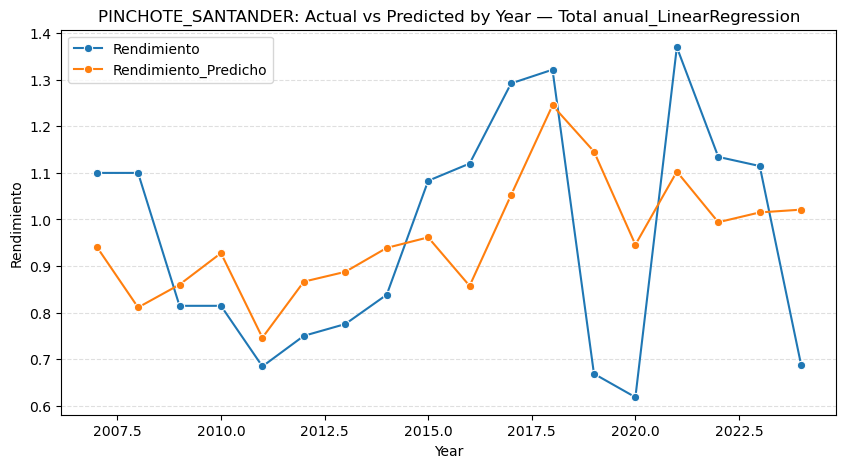

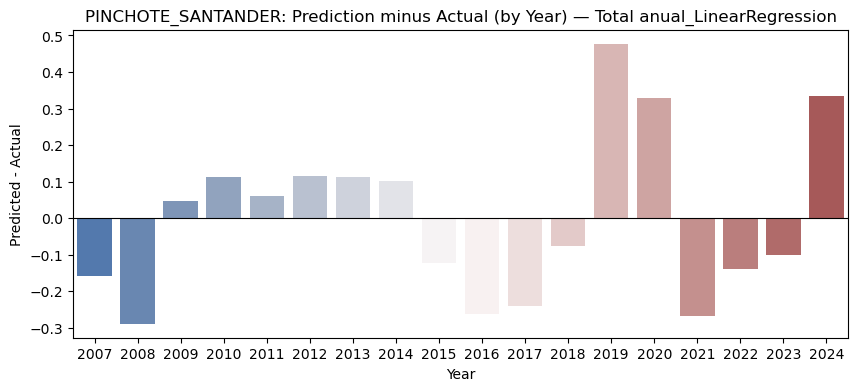

,Year,Rendimiento,Rendimiento_Predicho,diff
0,2007,1.100000,0.941745,-0.158255
1,2008,1.100000,0.810936,-0.289064
2,2009,0.814484,0.860054,0.045570
3,2010,0.814483,0.927660,0.113177
4,2011,0.684340,0.746033,0.061693
5,2012,0.750000,0.866422,0.116422
6,2013,0.775300,0.887486,0.112186
7,2014,0.838326,0.938930,0.100604
8,2015,1.083099,0.961529,-0.121569
9,2016,1.120136,0.857333,-0.262804


Processing PUENTE NACIONAL_SANTANDER


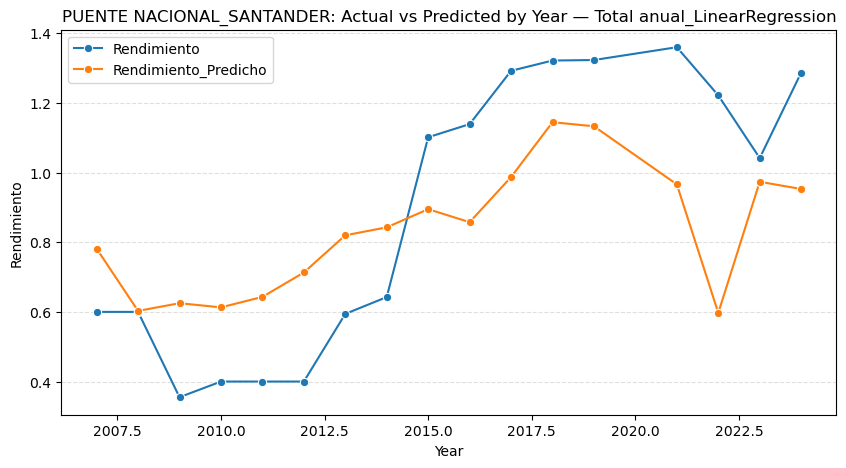

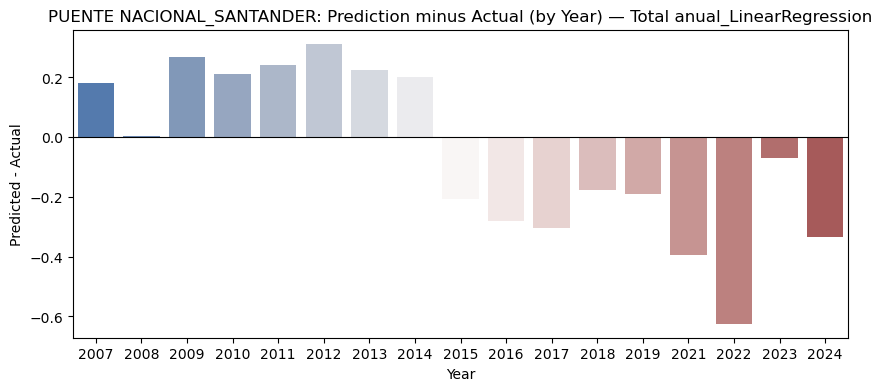

,Year,Rendimiento,Rendimiento_Predicho,diff
0,2007,0.600000,0.781504,0.181504
1,2008,0.600000,0.602815,0.002815
2,2009,0.354957,0.624982,0.270025
3,2010,0.400000,0.612942,0.212942
4,2011,0.400000,0.643006,0.243006
5,2012,0.400000,0.713107,0.313107
6,2013,0.594248,0.819925,0.225677
7,2014,0.642555,0.842793,0.200238
8,2015,1.101485,0.894959,-0.206526
9,2016,1.139157,0.857521,-0.281636


Processing SAN BENITO_SANTANDER


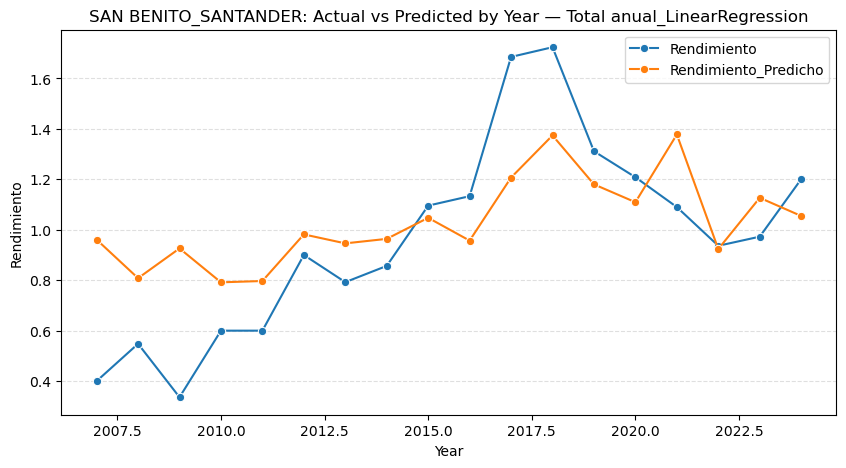

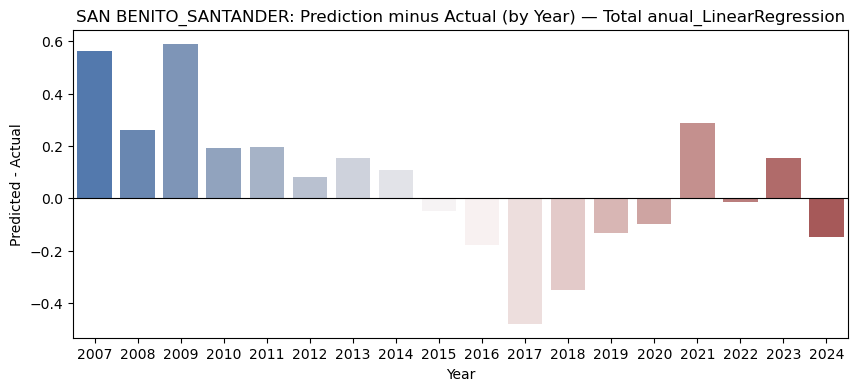

,Year,Rendimiento,Rendimiento_Predicho,diff
0,2007,0.400000,0.960880,0.560880
1,2008,0.547945,0.808069,0.260124
2,2009,0.336103,0.926114,0.590010
3,2010,0.600000,0.791648,0.191648
4,2011,0.600000,0.796876,0.196876
5,2012,0.900000,0.981683,0.081683
6,2013,0.792329,0.946073,0.153744
7,2014,0.856738,0.963942,0.107205
8,2015,1.095694,1.047421,-0.048273
9,2016,1.133167,0.957089,-0.176078


Processing SAN GIL_SANTANDER


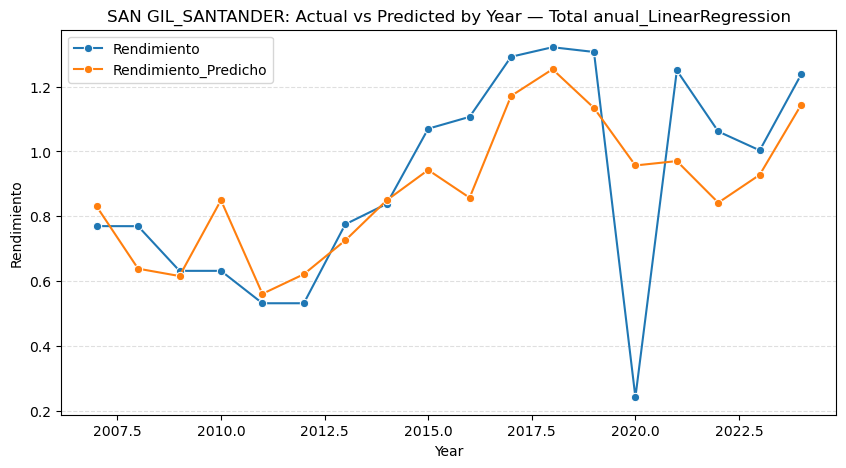

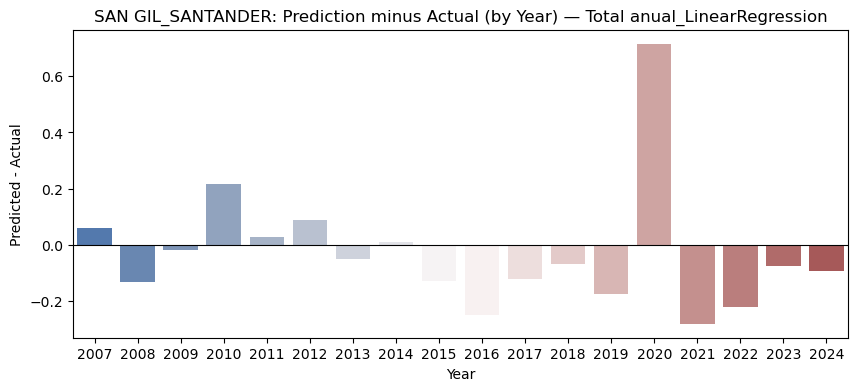

,Year,Rendimiento,Rendimiento_Predicho,diff
0,2007,0.769697,0.830488,0.060791
1,2008,0.769461,0.638397,-0.131064
2,2009,0.631650,0.615611,-0.016038
3,2010,0.631647,0.849686,0.218039
4,2011,0.531651,0.560671,0.029020
5,2012,0.531651,0.621295,0.089644
6,2013,0.775301,0.725737,-0.049564
7,2014,0.838325,0.849403,0.011077
8,2015,1.070270,0.942912,-0.127358
9,2016,1.106871,0.857297,-0.249574


Processing SUAITA_SANTANDER


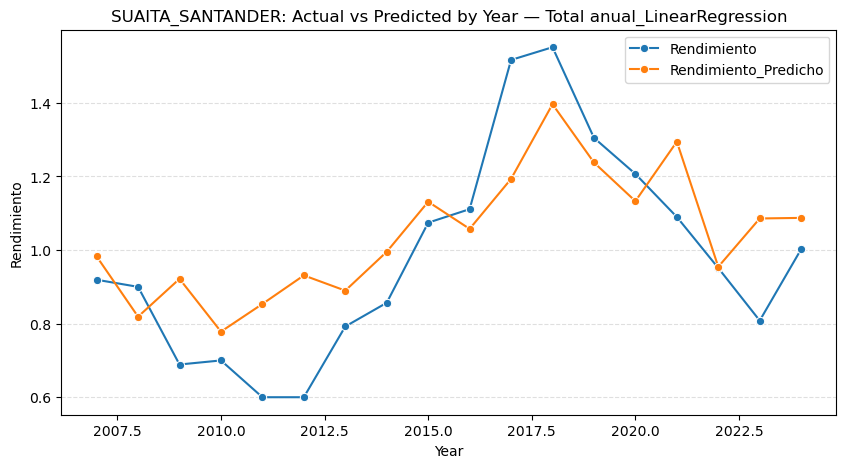

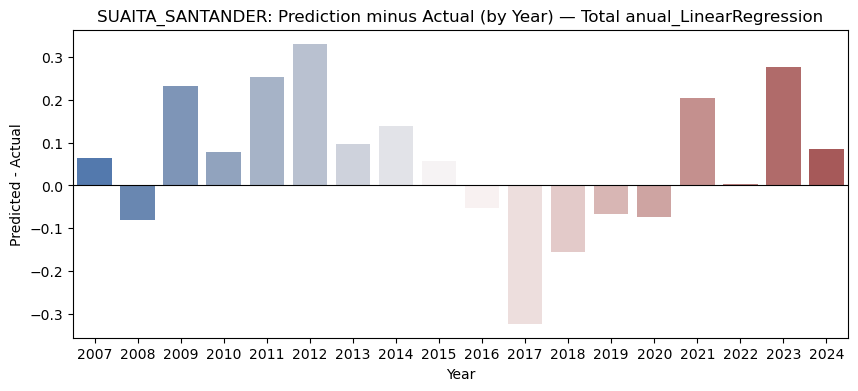

,Year,Rendimiento,Rendimiento_Predicho,diff
0,2007,0.919328,0.982763,0.063436
1,2008,0.900000,0.818949,-0.081051
2,2009,0.688915,0.921800,0.232885
3,2010,0.700000,0.778287,0.078287
4,2011,0.599997,0.853526,0.253529
5,2012,0.600000,0.931167,0.331167
6,2013,0.792331,0.889782,0.097450
7,2014,0.856739,0.995356,0.138616
8,2015,1.074465,1.131371,0.056907
9,2016,1.111215,1.057611,-0.053604


Processing VALLE DE SAN JOSE_SANTANDER


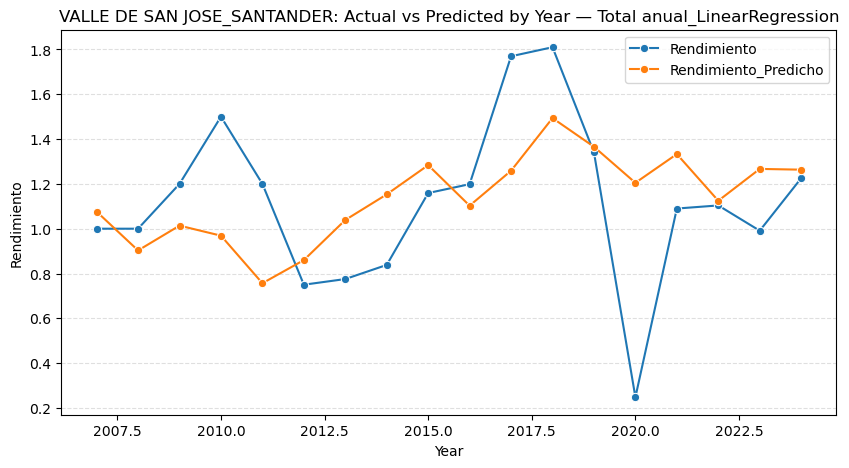

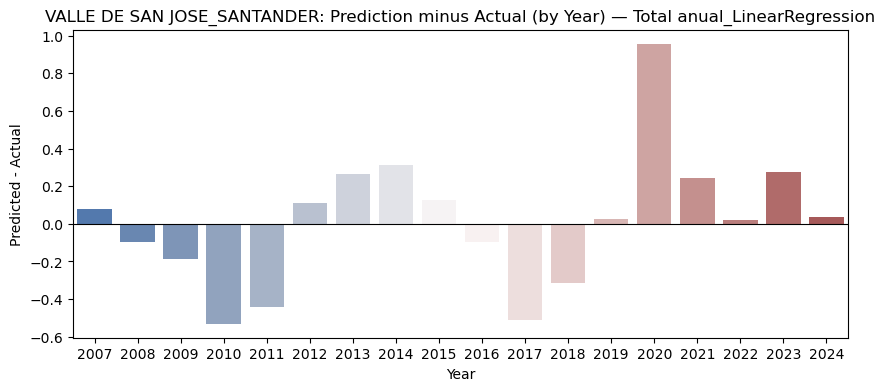

,Year,Rendimiento,Rendimiento_Predicho,diff
0,2007,1.000000,1.076251,0.076251
1,2008,1.000000,0.902947,-0.097053
2,2009,1.200000,1.013696,-0.186304
3,2010,1.500000,0.968891,-0.531109
4,2011,1.200000,0.756644,-0.443356
5,2012,0.750000,0.859863,0.109863
6,2013,0.775303,1.038887,0.263583
7,2014,0.838327,1.153227,0.314899
8,2015,1.159141,1.283672,0.124531
9,2016,1.198779,1.102808,-0.095971


In [109]:
plot_actual_vs_predicted('Total anual_LinearRegression')